## 1. Imports & configuration

In [5]:
import os
import re
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Union

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats, ndimage
from scipy.ndimage import label, center_of_mass

import nibabel as nib

warnings.filterwarnings('ignore')

# ── Thème graphique ──────────────────────────────────────────────────────────
PALETTE = {
    'primary'   : '#1A535C',
    'secondary' : '#4ECDC4',
    'accent'    : '#FF6B6B',
    'warn'      : '#FFE66D',
    'neutral'   : '#F7FFF7',
}

plt.rcParams.update({
    'figure.dpi'       : 120,
    'axes.titlesize'   : 11,
    'axes.labelsize'   : 10,
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'grid.linestyle'   : '--',
})

# ── Chemin racine ──────────────────────────────────────────────────────────
ROOT = Path("/Users/arslenebouhadjera/Stage_Arslène_2026/Documents/StageNoé2025/"
            "pipeline-vessel-enhancement-master/data/Bullitt_V2")

assert ROOT.exists(), f"Dossier introuvable : {ROOT}"
print(f"Racine de la base : {ROOT.resolve()}")

Racine de la base : /Users/arslenebouhadjera/Stage_Arslène_2026/Documents/StageNoé2025/pipeline-vessel-enhancement-master/data/Bullitt_V2


## 2. Inventaire des patients

In [6]:

print("\n" + "=" * 60)
print("INVENTAIRE DES PATIENTS")
print("=" * 60)

# Récupération des dossiers patients (format NormalXXX-MRA)
patient_dirs = sorted(
    [d for d in ROOT.iterdir()
     if d.is_dir() and re.match(r"Normal\d+-MRA", d.name)],
    key=lambda d: int(re.search(r"\d+", d.name).group())
)

print(f"Patients trouvés : {len(patient_dirs)}")
for d in patient_dirs:
    print(f"  {d.name}")

# Structure détaillée du premier patient (référence)
def list_patient_files(patient_dir: Path) -> dict:
    """Retourne la liste des fichiers d'un patient."""
    files = sorted(patient_dir.rglob("*"))
    return {
        "dir": patient_dir.name,
        "files": [f.relative_to(patient_dir) for f in files if f.is_file()]
    }

if patient_dirs:
    p0 = list_patient_files(patient_dirs[0])
    print(f"\nStructure de {p0['dir']} (référence) :")
    for f in p0["files"][:10]:  # affichage limité
        print(f"  {f}")
    if len(p0["files"]) > 10:
        print(f"  ... et {len(p0['files']) - 10} autres fichiers")



INVENTAIRE DES PATIENTS
Patients trouvés : 1
  Normal002-MRA

Structure de Normal002-MRA (référence) :
  .DS_Store
  bifurcationMaskIso.nii
  bifurcationMaskIso.nii.gz
  bifurcationMaskIso_S.nii
  bifurcationMaskIso_S.nii.gz
  binaryVesselsIso.nii
  binaryVesselsIso.nii.gz
  binaryVesselsIso_S.nii
  binaryVesselsIso_S.nii.gz
  brainMaskIso.nii
  ... et 8 autres fichiers


In [7]:

print("\n" + "=" * 60)
print("COLLECTE DES FICHIERS NIFTI")
print("=" * 60)

def find_files(patient_dir: Path) -> Tuple[Optional[Path], Optional[Path]]:
    """
    Recherche les fichiers MRA et masque pour un patient.
    
    Retourne :
        (mra_path, mask_path) — None si absent.
    """
    nifti_exts = (".nii", ".nii.gz")
    all_nii = [f for f in patient_dir.rglob("*")
               if f.is_file() and any(str(f).endswith(e) for e in nifti_exts)]

    mra, mask = None, None
    for f in all_nii:
        name_lower = f.name.lower()
        # Heuristiques de détection (à adapter selon nomenclature réelle)
        if any(k in name_lower for k in ("mask", "vessel", "seg", "label", "gt")):
            mask = f
        elif any(k in name_lower for k in ("mra", "image", "angio")) or mra is None:
            mra = f
    return mra, mask

records = []
for d in patient_dirs:
    pid = int(re.search(r"\d+", d.name).group())
    mra, mask = find_files(d)
    records.append({
        "id": pid,
        "name": d.name,
        "mra": mra,
        "mask": mask,
        "dir": d
    })

has_mra  = [r for r in records if r["mra"] is not None]
has_mask = [r for r in records if r["mask"] is not None]

print(f"Volumes MRA    trouvés : {len(has_mra)} / {len(records)}")
print(f"Masques voxels trouvés : {len(has_mask)} / {len(records)}")
print(f"  (attendus : 100 images, 33 masques voxeliques)")



COLLECTE DES FICHIERS NIFTI
Volumes MRA    trouvés : 1 / 1
Masques voxels trouvés : 1 / 1
  (attendus : 100 images, 33 masques voxeliques)


In [8]:

print("\n" + "=" * 60)
print("STATISTIQUES VOLUMÉTRIQUES — MRA")
print("=" * 60)

def volume_stats(path: Path) -> Dict:
    """Extrait les statistiques d'un volume NIfTI."""
    img = nib.load(str(path))
    data = img.get_fdata(dtype=np.float32)
    hdr = img.header
    vox = np.abs(np.diag(hdr.get_zooms()[:3]))  # spacing en mm
    return {
        "shape": data.shape,
        "spacing_mm": tuple(np.round(hdr.get_zooms()[:3], 4)),
        "min": float(data.min()),
        "max": float(data.max()),
        "mean": float(data.mean()),
        "std": float(data.std()),
        "dtype": str(data.dtype),
    }

# Analyse de tous les volumes MRA disponibles
stats_list = []
for r in has_mra:
    try:
        s = volume_stats(r["mra"])
        s["patient"] = r["name"]
        s["pid"] = r["id"]
        stats_list.append(s)
    except Exception as e:
        print(f"  ⚠ Erreur {r['name']} : {e}")

if stats_list:
    shapes = [s["shape"] for s in stats_list]
    spacings = [s["spacing_mm"] for s in stats_list]

    print(f"\n--- Géométrie ---")
    print(f"  Shapes uniques : {set(shapes)}")
    print(f"  Spacings (mm)  : {set(spacings)}")

    print(f"\n--- Intensités (moyenne sur {len(stats_list)} volumes) ---")
    print(f"  Min  = {np.mean([s['min'] for s in stats_list]):.1f}  (range : [{min(s['min'] for s in stats_list):.1f}, {max(s['min'] for s in stats_list):.1f}])")
    print(f"  Max  = {np.mean([s['max'] for s in stats_list]):.1f}  (range : [{min(s['max'] for s in stats_list):.1f}, {max(s['max'] for s in stats_list):.1f}])")
    print(f"  Mean = {np.mean([s['mean'] for s in stats_list]):.1f} ± {np.std([s['mean'] for s in stats_list]):.1f}")
    print(f"  Std  = {np.mean([s['std'] for s in stats_list]):.1f}")


STATISTIQUES VOLUMÉTRIQUES — MRA

--- Géométrie ---
  Shapes uniques : {(279, 341, 178)}
  Spacings (mm)  : {(0.5134, 0.5134, 0.5134)}

--- Intensités (moyenne sur 1 volumes) ---
  Min  = -13.0  (range : [-13.0, -13.0])
  Max  = 1153.0  (range : [1153.0, 1153.0])
  Mean = 92.3 ± 0.0
  Std  = 55.7


In [9]:
print("\n" + "=" * 60)
print("ANALYSE DES MASQUES VASCULAIRES")
print("=" * 60)

mask_stats = []
for r in has_mask:
    try:
        img = nib.load(str(r["mask"]))
        data = img.get_fdata(dtype=np.float32)
        n_vox = data.size
        n_fg = int((data > 0).sum())
        mask_stats.append({
            "patient": r["name"],
            "pid": r["id"],
            "voxels_total": n_vox,
            "voxels_vessel": n_fg,
            "vessel_ratio_%": round(100 * n_fg / n_vox, 4),
            "unique_labels": list(np.unique(data).astype(int))
        })
    except Exception as e:
        print(f"  ⚠ Erreur masque {r['name']} : {e}")

if mask_stats:
    ratios = [m["vessel_ratio_%"] for m in mask_stats]
    print(f"Masques analysés : {len(mask_stats)}")
    print(f"Charge vasculaire (% voxels foreground) :")
    print(f"  Moyenne : {np.mean(ratios):.3f}%")
    print(f"  Min     : {min(ratios):.3f}%")
    print(f"  Max     : {max(ratios):.3f}%")
    print(f"  Écart-type : {np.std(ratios):.3f}%")
    print(f"Labels uniques (exemple) : {mask_stats[0]['unique_labels']}")



ANALYSE DES MASQUES VASCULAIRES
Masques analysés : 1
Charge vasculaire (% voxels foreground) :
  Moyenne : 3.752%
  Min     : 3.752%
  Max     : 3.752%
  Écart-type : 0.000%
Labels uniques (exemple) : [0, 255]



VISUALISATION — COUPES ANATOMIQUES
Visualisation du premier patient avec masque :


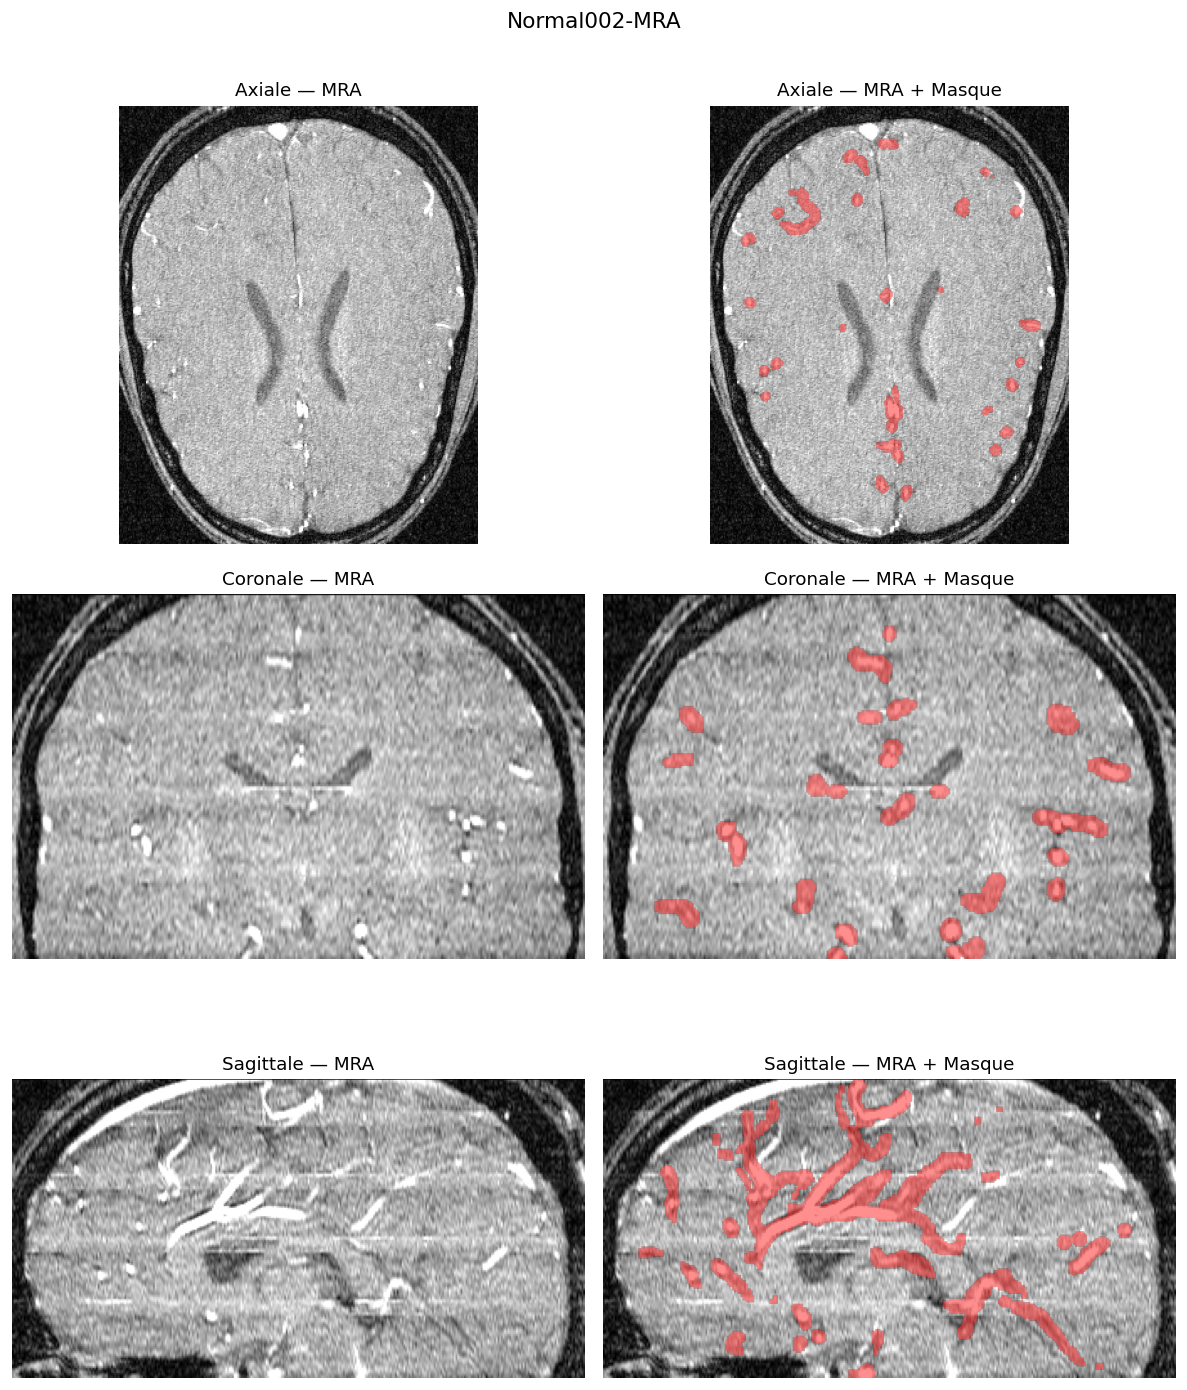

In [10]:
print("\n" + "=" * 60)
print("VISUALISATION — COUPES ANATOMIQUES")
print("=" * 60)

def show_patient(record: dict, percentile_clip: Tuple[int, int] = (1, 99)):
    """
    Affiche les coupes axiale, coronale et sagittale.
    - MRA seule (gauche)
    - MRA + masque superposé (droite) si disponible
    """
    if record["mra"] is None:
        print(f"  ⚠ Pas de MRA pour {record['name']}")
        return

    # Chargement et normalisation
    img = nib.load(str(record["mra"]))
    vol = img.get_fdata(dtype=np.float32)
    lo, hi = np.percentile(vol, percentile_clip)
    vol_n = np.clip((vol - lo) / (hi - lo + 1e-9), 0, 1)

    # Masque
    mask_vol = None
    if record["mask"] is not None:
        mask_vol = nib.load(str(record["mask"])).get_fdata(dtype=np.float32) > 0

    # Coupes centrales
    cx, cy, cz = [s // 2 for s in vol_n.shape[:3]]
    cuts = [
        ("Axiale", vol_n[:, :, cz], None if mask_vol is None else mask_vol[:, :, cz]),
        ("Coronale", vol_n[:, cy, :], None if mask_vol is None else mask_vol[:, cy, :]),
        ("Sagittale", vol_n[cx, :, :], None if mask_vol is None else mask_vol[cx, :, :]),
    ]

    n_cols = 2 if mask_vol is not None else 1
    fig, axes = plt.subplots(3, n_cols, figsize=(5 * n_cols, 12))
    if n_cols == 1:
        axes = axes[:, np.newaxis]

    for row, (title, mra_cut, msk_cut) in enumerate(cuts):
        # Colonne gauche : MRA
        axes[row, 0].imshow(mra_cut.T, cmap="gray", origin="lower")
        axes[row, 0].set_title(f"{title} — MRA")
        axes[row, 0].axis("off")

        # Colonne droite : MRA + masque (si disponible)
        if mask_vol is not None:
            axes[row, 1].imshow(mra_cut.T, cmap="gray", origin="lower")
            overlay = np.zeros((*msk_cut.T.shape, 4))
            overlay[msk_cut.T > 0] = [1, 0.2, 0.2, 0.55]  # rouge semi-transparent
            axes[row, 1].imshow(overlay, origin="lower")
            axes[row, 1].set_title(f"{title} — MRA + Masque")
            axes[row, 1].axis("off")

    fig.suptitle(record["name"], fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

# Visualisation du premier patient avec masque
if has_mask:
    print("Visualisation du premier patient avec masque :")
    show_patient(has_mask[0])

Histogramme du premier patient :


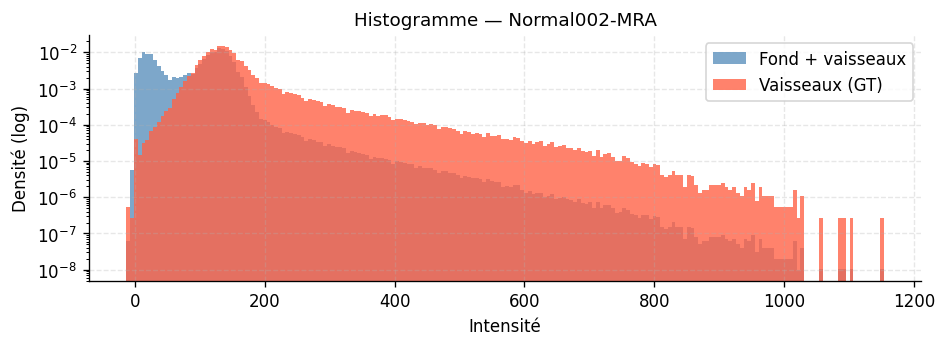

In [11]:
def plot_intensity_histogram(record: dict, bins: int = 200):
    """
    Histogramme des intensités MRA (log scale).
    Superposition du masque vasculaire si disponible.
    """
    if record["mra"] is None:
        return

    vol = nib.load(str(record["mra"])).get_fdata(dtype=np.float32).ravel()
    mask = None
    if record["mask"] is not None:
        mask = nib.load(str(record["mask"])).get_fdata(dtype=np.float32).ravel() > 0

    fig, ax = plt.subplots(figsize=(8, 3))
    ax.hist(vol, bins=bins, color="steelblue", alpha=0.7,
            label="Fond + vaisseaux", log=True, density=True)
    if mask is not None:
        ax.hist(vol[mask], bins=bins, color="tomato", alpha=0.8,
                label="Vaisseaux (GT)", log=True, density=True)
    ax.set_xlabel("Intensité")
    ax.set_ylabel("Densité (log)")
    ax.set_title(f"Histogramme — {record['name']}")
    ax.legend()
    plt.tight_layout()
    plt.show()

if has_mask:
    print("Histogramme du premier patient :")
    plot_intensity_histogram(has_mask[0])


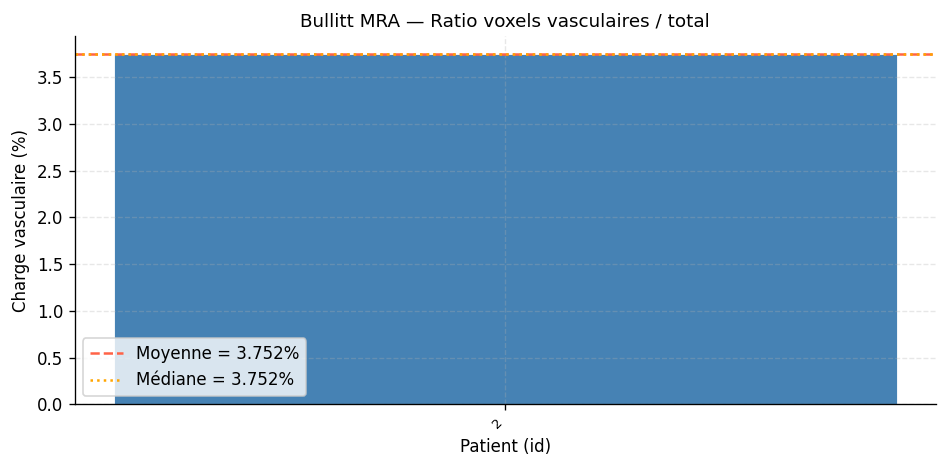

In [12]:
if mask_stats:
    ids = [m["patient"] for m in mask_stats]
    ratios = [m["vessel_ratio_%"] for m in mask_stats]
    pids = [m["pid"] for m in mask_stats]

    fig, ax = plt.subplots(figsize=(max(8, len(ids) * 0.5), 4))

    bars = ax.bar(range(len(ids)), ratios, color="steelblue",
                  edgecolor="white", linewidth=0.5)

    ax.axhline(np.mean(ratios), color="tomato", linestyle="--",
               linewidth=1.5, label=f"Moyenne = {np.mean(ratios):.3f}%")
    ax.axhline(np.median(ratios), color="orange", linestyle=":",
               linewidth=1.5, label=f"Médiane = {np.median(ratios):.3f}%")

    ax.set_xticks(range(len(ids)))
    ax.set_xticklabels([str(p) for p in pids], rotation=45, ha="right", fontsize=8)
    ax.set_xlabel("Patient (id)")
    ax.set_ylabel("Charge vasculaire (%)")
    ax.set_title("Bullitt MRA — Ratio voxels vasculaires / total")
    ax.legend()
    plt.tight_layout()
    plt.show()


In [13]:
print("\n" + "=" * 60)
print("RÉSUMÉ DE L'ANALYSE")
print("=" * 60)

print(f"  Patients totaux        : {len(patient_dirs)}")
print(f"  Patients avec MRA      : {len(has_mra)}")
print(f"  Patients avec masque   : {len(has_mask)}")
print(f"  Ratio moyen vasculaire : {np.mean([m['vessel_ratio_%'] for m in mask_stats]):.3f}%")
print(f"  Écart-type             : {np.std([m['vessel_ratio_%'] for m in mask_stats]):.3f}%")




RÉSUMÉ DE L'ANALYSE
  Patients totaux        : 1
  Patients avec MRA      : 1
  Patients avec masque   : 1
  Ratio moyen vasculaire : 3.752%
  Écart-type             : 0.000%



CHARGEMENT DU DATASET BULLITT V2
  Dossier racine : /Users/arslenebouhadjera/Stage_Arslène_2026/Documents/StageNoé2025/pipeline-vessel-enhancement-master/data/Bullitt_V2
  Patients détectés : 1

─── Patient 002 : Normal002-MRA ───
  ✓ MRA chargé : (279, 341, 178) (spacing=(array([0.5134, 0.    , 0.    ], dtype=float32), array([0.    , 0.5134, 0.    ], dtype=float32), array([0.    , 0.    , 0.5134], dtype=float32)))
  ✓ Masque chargé : (279, 341, 178)
    Voxels vasculaires : 635,449 (3.75%)
    Composantes : 29
    Couverture slices : 178/178
    Intensité intra-masque : mean=152.3, std=74.0

Patients chargés : 1 / 1
Avec masque      : 1 / 1

TABLEAU RÉCAPITULATIF


,patient,mra_present,mask_present,compatible,shape_x,shape_y,shape_z,spacing_x,spacing_y,spacing_z,vessel_voxels,vessel_ratio_pct,n_components,slice_coverage,slice_coverage_pct,intensity_mean,intensity_median,intensity_std,intensity_p5,intensity_p95
pid,,,,,,,,,,,,,,,,,,,,
2,Normal002-MRA,True,True,True,279,341,178,"[0.5134, 0.0, 0.0]","[0.0, 0.5134, 0.0]","[0.0, 0.0, 0.5134]",635449,3.7523,29,178,100.0,152.298645,136.0,74.000656,89.0,282.0



✓ Exporté : /Users/arslenebouhadjera/Stage_Arslène_2026/Documents/StageNoé2025/pipeline-vessel-enhancement-master/data/Bullitt_V2/bullitt_v2_analysis_summary.csv

VISUALISATIONS

Visualisation du premier patient avec masque (P002) :


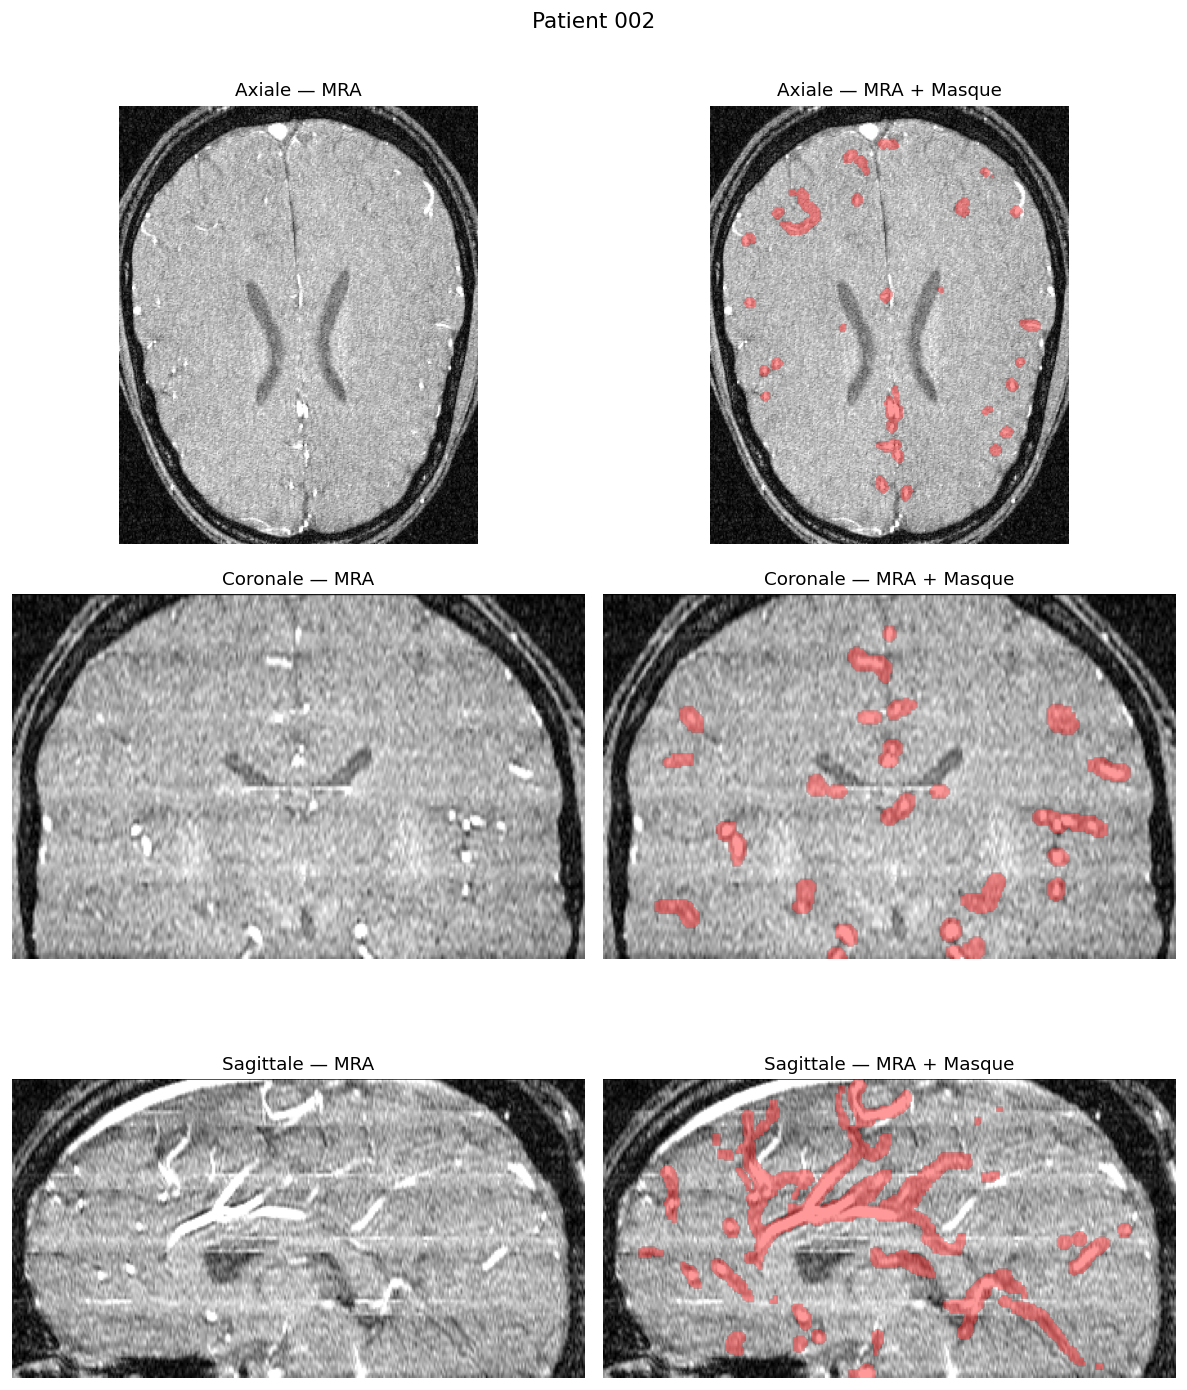

Histogramme du premier patient (P002) :


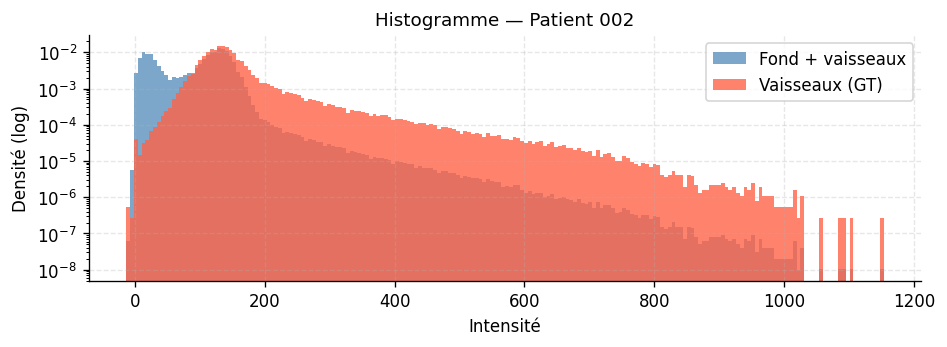

Résumé des ratios vasculaires :


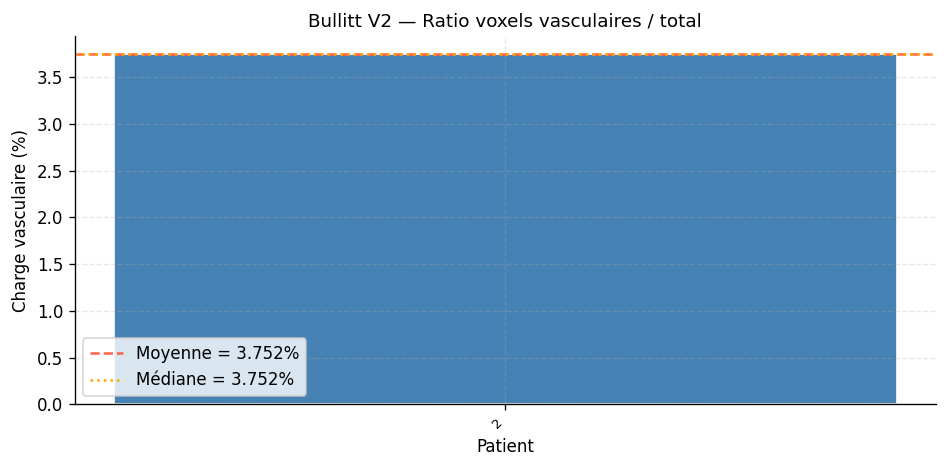


STATISTIQUES GLOBALES
  Patients totaux          : 1
  Patients avec MRA        : 1
  Patients avec masque     : 1
  Patients compatibles     : 1

  Ratio vasculaire moyen    : 3.752%
  Ratio vasculaire médian   : 3.752%
  Écart-type                : nan%
  Min/Max                   : 3.752% / 3.752%

✅ Analyse Bullitt V2 terminée.


In [14]:
"""
================================================================================
BULLITT V2 LOADER
================================================================================
Analyse des volumes MRA cérébraux et des masques vasculaires associés.
Structure attendue :
    data/Bullitt_V2/
        Normal001-MRA/
            *.nii ou *.nii.gz (MRA)
            *mask*.nii ou *vessel*.nii (masque vasculaire)
        Normal002-MRA/
            ...
================================================================================
"""

# =============================================================================
# IMPORTS
# =============================================================================

from pathlib import Path
from typing import Dict, Optional, Tuple, List, Any
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import nibabel as nib
from scipy import ndimage, stats
from scipy.ndimage import label, center_of_mass, distance_transform_edt
from scipy.stats import gaussian_kde
from skimage.morphology import skeletonize
from skimage.measure import find_contours

warnings.filterwarnings('ignore')

# =============================================================================
# CONFIGURATION
# =============================================================================

DATA_DIR = Path("/Users/arslenebouhadjera/Stage_Arslène_2026/Documents/StageNoé2025/"
                "pipeline-vessel-enhancement-master/data/Bullitt_V2")

# Pattern des dossiers patients
PATIENT_PATTERN = re.compile(r"Normal(\d+)-MRA")

# Structures vasculaires attendues (détection heuristique)
MASK_KEYWORDS = [
    "mask",
    "vessel",
    "seg",
    "label",
    "gt",
    "groundtruth",
]

MRA_KEYWORDS = [
    "mra",
    "image",
    "angio",
    "volume",
]

# =============================================================================
# FONCTIONS DE CHARGEMENT NIFTI
# =============================================================================

def load_nifti(path: Path) -> Tuple[np.ndarray, Dict]:
    """
    Charge un volume NIfTI.
    
    Retourne:
        volume  : ndarray [x, y, z] ou [z, y, x] (selon NIfTI)
        metadata: dict avec header, spacing, shape
    """
    img = nib.load(str(path))
    data = img.get_fdata(dtype=np.float32)
    header = img.header
    spacing = np.abs(np.diag(header.get_zooms()[:3]))
    
    metadata = {
        "shape": data.shape,
        "spacing": spacing,
        "spacing_xyz": tuple(np.round(spacing, 4)),
        "dtype": str(data.dtype),
        "header": header,
    }
    
    return data, metadata


def load_nifti_safe(path: Path) -> Optional[Tuple[np.ndarray, Dict]]:
    """Charge un NIfTI avec gestion d'erreur."""
    try:
        return load_nifti(path)
    except Exception as e:
        print(f"  ⚠ Erreur chargement {path.name}: {e}")
        return None


# =============================================================================
# DÉTECTION DES FICHIERS
# =============================================================================

def detect_patient_dirs(data_dir: Path) -> List[Tuple[int, Path]]:
    """Détecte tous les dossiers patients valides."""
    patients = []
    for d in data_dir.iterdir():
        if not d.is_dir():
            continue
        match = PATIENT_PATTERN.match(d.name)
        if match:
            pid = int(match.group(1))
            patients.append((pid, d))
    return sorted(patients, key=lambda x: x[0])


def find_mra_and_mask(patient_dir: Path) -> Tuple[Optional[Path], Optional[Path]]:
    """
    Recherche les fichiers MRA et masque dans le dossier patient.
    
    Retourne:
        (mra_path, mask_path) — None si absent
    """
    nifti_exts = (".nii", ".nii.gz")
    all_nii = [
        f for f in patient_dir.rglob("*")
        if f.is_file() and any(str(f).endswith(e) for e in nifti_exts)
    ]
    
    mra, mask = None, None
    
    for f in all_nii:
        name_lower = f.name.lower()
        
        # Détection du masque
        if any(k in name_lower for k in MASK_KEYWORDS):
            if mask is None:  # Priorité au premier trouvé
                mask = f
        # Détection du MRA
        elif any(k in name_lower for k in MRA_KEYWORDS):
            if mra is None:  # Priorité au premier trouvé
                mra = f
        # Fallback: si aucun mot-clé spécifique, on prend le plus grand volume
        elif mra is None:
            mra = f
    
    return mra, mask


# =============================================================================
# ANALYSE DES MASQUES
# =============================================================================

def compute_mask_stats(mask_data: np.ndarray, spacing: np.ndarray) -> Dict:
    """
    Calcule les statistiques d'un masque binaire.
    
    Retourne:
        - voxels_total: nombre total de voxels
        - voxels_foreground: nombre de voxels > 0
        - ratio_pct: pourcentage de voxels vasculaires
        - n_components: nombre de composantes connexes
        - bbox: boîte englobante (min, max) en indices
        - bbox_size_mm: taille de la bbox en mm
        - center_of_mass: centre de masse en coordonnées voxels
        - slice_coverage: nombre de slices couvertes
    """
    if mask_data is None or mask_data.size == 0:
        return {
            "voxels_total": 0,
            "voxels_foreground": 0,
            "ratio_pct": 0.0,
            "n_components": 0,
            "bbox": None,
            "bbox_size_mm": None,
            "center_of_mass": None,
            "slice_coverage": 0,
        }
    
    # Binarisation
    binary = mask_data > 0
    n_vox = binary.size
    n_fg = int(binary.sum())
    ratio_pct = 100 * n_fg / n_vox if n_vox > 0 else 0.0
    
    # Composantes connexes
    labeled, n_cc = label(binary)
    
    # Bbox
    coords = np.where(binary)
    if len(coords[0]) > 0:
        bbox = (
            (int(coords[0].min()), int(coords[0].max())),
            (int(coords[1].min()), int(coords[1].max())),
            (int(coords[2].min()), int(coords[2].max())),
        )
        bbox_size_vox = (
            bbox[0][1] - bbox[0][0] + 1,
            bbox[1][1] - bbox[1][0] + 1,
            bbox[2][1] - bbox[2][0] + 1,
        )
        bbox_size_mm = tuple(bbox_size_vox[i] * spacing[i] for i in range(3))
        com = center_of_mass(binary)
    else:
        bbox = None
        bbox_size_mm = None
        com = None
    
    # Couverture en slices (projection)
    slice_coverage = int((binary.sum(axis=(0, 1)) > 0).sum())
    
    return {
        "voxels_total": n_vox,
        "voxels_foreground": n_fg,
        "ratio_pct": round(ratio_pct, 4),
        "n_components": n_cc,
        "bbox": bbox,
        "bbox_size_mm": bbox_size_mm,
        "center_of_mass": com,
        "slice_coverage": slice_coverage,
        "slice_coverage_pct": round(100 * slice_coverage / mask_data.shape[2], 2),
    }


def compute_intensity_stats(volume: np.ndarray, mask: np.ndarray) -> Dict:
    """Calcule les statistiques d'intensité dans une région masquée."""
    if volume is None or mask is None or mask.sum() == 0:
        return {
            "mean": np.nan,
            "median": np.nan,
            "std": np.nan,
            "min": np.nan,
            "max": np.nan,
            "p5": np.nan,
            "p95": np.nan,
            "skew": np.nan,
            "kurtosis": np.nan,
        }
    
    values = volume[mask > 0].ravel()
    if len(values) == 0:
        return {k: np.nan for k in ["mean", "median", "std", "min", "max", "p5", "p95", "skew", "kurtosis"]}
    
    return {
        "mean": float(np.mean(values)),
        "median": float(np.median(values)),
        "std": float(np.std(values)),
        "min": float(np.min(values)),
        "max": float(np.max(values)),
        "p5": float(np.percentile(values, 5)),
        "p95": float(np.percentile(values, 95)),
        "skew": float(stats.skew(values)),
        "kurtosis": float(stats.kurtosis(values)),
    }


# =============================================================================
# CHARGEUR PRINCIPAL
# =============================================================================

def load_bullitt_dataset(data_dir: Path) -> Dict[str, Dict]:
    """
    Charge l'intégralité du dataset Bullitt V2.
    
    Retourne:
        Dictionnaire {patient_id: {
            "mra": ndarray,
            "mask": ndarray,
            "spacing": ndarray,
            "mra_path": Path,
            "mask_path": Path,
            "mask_stats": dict,
            "intensity_stats": dict,
        }}
    """
    patients = detect_patient_dirs(data_dir)
    dataset = {}
    
    print("\n" + "=" * 60)
    print("CHARGEMENT DU DATASET BULLITT V2")
    print("=" * 60)
    print(f"  Dossier racine : {data_dir}")
    print(f"  Patients détectés : {len(patients)}")
    print()
    
    for pid, patient_dir in patients:
        print(f"─── Patient {pid:03d} : {patient_dir.name} ───")
        
        # Détection des fichiers
        mra_path, mask_path = find_mra_and_mask(patient_dir)
        
        # Chargement du MRA
        mra_data = None
        mra_meta = None
        if mra_path is not None:
            result = load_nifti_safe(mra_path)
            if result is not None:
                mra_data, mra_meta = result
                print(f"  ✓ MRA chargé : {mra_data.shape} (spacing={mra_meta['spacing_xyz']})")
            else:
                print(f"  ✗ Échec chargement MRA")
        else:
            print(f"  ✗ Aucun fichier MRA trouvé")
        
        # Chargement du masque
        mask_data = None
        mask_meta = None
        if mask_path is not None:
            result = load_nifti_safe(mask_path)
            if result is not None:
                mask_data, mask_meta = result
                print(f"  ✓ Masque chargé : {mask_data.shape}")
            else:
                print(f"  ✗ Échec chargement masque")
        else:
            print(f"  ✗ Aucun masque trouvé")
        
        # Vérification de compatibilité spatiale
        compat = True
        if mra_meta is not None and mask_meta is not None:
            if mra_meta["shape"] != mask_meta["shape"]:
                print(f"  ⚠ Incompatibilité : MRA {mra_meta['shape']} vs Masque {mask_meta['shape']}")
                compat = False
        
        # Statistiques
        spacing = mra_meta["spacing"] if mra_meta else np.array([1.0, 1.0, 1.0])
        
        if mask_data is not None:
            mask_stats = compute_mask_stats(mask_data, spacing)
            print(f"    Voxels vasculaires : {mask_stats['voxels_foreground']:,} ({mask_stats['ratio_pct']:.2f}%)")
            print(f"    Composantes : {mask_stats['n_components']}")
            print(f"    Couverture slices : {mask_stats['slice_coverage']}/{mask_data.shape[2]}")
        else:
            mask_stats = None
        
        if mra_data is not None and mask_data is not None and mask_data.sum() > 0:
            intensity_stats = compute_intensity_stats(mra_data, mask_data)
            print(f"    Intensité intra-masque : mean={intensity_stats['mean']:.1f}, std={intensity_stats['std']:.1f}")
        else:
            intensity_stats = None
        
        # Stockage
        dataset[f"Normal{pid:03d}-MRA"] = {
            "pid": pid,
            "mra": mra_data,
            "mask": mask_data,
            "spacing": spacing,
            "mra_path": mra_path,
            "mask_path": mask_path,
            "mra_meta": mra_meta,
            "mask_meta": mask_meta,
            "mask_stats": mask_stats,
            "intensity_stats": intensity_stats,
            "compatible": compat,
        }
        
        print()
    
    print("=" * 60)
    n_loaded = sum(1 for v in dataset.values() if v["mra"] is not None)
    n_masked = sum(1 for v in dataset.values() if v["mask"] is not None)
    print(f"Patients chargés : {n_loaded} / {len(patients)}")
    print(f"Avec masque      : {n_masked} / {len(patients)}")
    print("=" * 60)
    
    return dataset


# =============================================================================
# TABLEAU RÉCAPITULATIF
# =============================================================================

def build_summary_dataframe(dataset: Dict[str, Dict]) -> pd.DataFrame:
    """Construit un DataFrame récapitulatif de toutes les métriques."""
    rows = []
    
    for name, data in dataset.items():
        pid = data["pid"]
        mra_meta = data.get("mra_meta")
        mask_stats = data.get("mask_stats")
        intensity_stats = data.get("intensity_stats")
        
        row = {
            "patient": name,
            "pid": pid,
            "mra_present": data["mra"] is not None,
            "mask_present": data["mask"] is not None,
            "compatible": data["compatible"],
        }
        
        # Métadonnées MRA
        if mra_meta:
            row.update({
                "shape_x": mra_meta["shape"][0],
                "shape_y": mra_meta["shape"][1],
                "shape_z": mra_meta["shape"][2],
                "spacing_x": mra_meta["spacing_xyz"][0],
                "spacing_y": mra_meta["spacing_xyz"][1],
                "spacing_z": mra_meta["spacing_xyz"][2],
            })
        
        # Statistiques masque
        if mask_stats:
            row.update({
                "vessel_voxels": mask_stats["voxels_foreground"],
                "vessel_ratio_pct": mask_stats["ratio_pct"],
                "n_components": mask_stats["n_components"],
                "slice_coverage": mask_stats["slice_coverage"],
                "slice_coverage_pct": mask_stats["slice_coverage_pct"],
            })
        
        # Statistiques d'intensité
        if intensity_stats:
            row.update({
                "intensity_mean": intensity_stats["mean"],
                "intensity_median": intensity_stats["median"],
                "intensity_std": intensity_stats["std"],
                "intensity_p5": intensity_stats["p5"],
                "intensity_p95": intensity_stats["p95"],
            })
        
        rows.append(row)
    
    df = pd.DataFrame(rows)
    if "pid" in df.columns:
        df = df.set_index("pid").sort_index()
    
    return df


# =============================================================================
# VISUALISATIONS
# =============================================================================

def plot_patient_overview(patient_data: Dict, title: Optional[str] = None):
    """
    Affiche un aperçu complet du patient : coupes MRA + masque superposé.
    """
    mra = patient_data["mra"]
    mask = patient_data["mask"]
    spacing = patient_data["spacing"]
    name = title or f"Patient {patient_data['pid']:03d}"
    
    if mra is None:
        print("  ⚠ Aucun MRA à visualiser")
        return
    
    # Normalisation MRA
    lo, hi = np.percentile(mra, (1, 99))
    mra_norm = np.clip((mra - lo) / (hi - lo + 1e-9), 0, 1)
    
    # Sélection des coupes centrales
    cx, cy, cz = [s // 2 for s in mra.shape[:3]]
    cuts = [
        ("Axiale", mra_norm[:, :, cz], mask[:, :, cz] if mask is not None else None),
        ("Coronale", mra_norm[:, cy, :], mask[:, cy, :] if mask is not None else None),
        ("Sagittale", mra_norm[cx, :, :], mask[cx, :, :] if mask is not None else None),
    ]
    
    n_cols = 2 if mask is not None else 1
    fig, axes = plt.subplots(3, n_cols, figsize=(5 * n_cols, 12))
    if n_cols == 1:
        axes = axes[:, np.newaxis]
    
    for row, (title_cut, mra_cut, mask_cut) in enumerate(cuts):
        # MRA seul
        axes[row, 0].imshow(mra_cut.T, cmap="gray", origin="lower")
        axes[row, 0].set_title(f"{title_cut} — MRA")
        axes[row, 0].axis("off")
        
        # MRA + masque
        if mask is not None and mask_cut is not None:
            axes[row, 1].imshow(mra_cut.T, cmap="gray", origin="lower")
            overlay = np.zeros((*mask_cut.T.shape, 4))
            overlay[mask_cut.T > 0] = [1, 0.2, 0.2, 0.5]
            axes[row, 1].imshow(overlay, origin="lower")
            axes[row, 1].set_title(f"{title_cut} — MRA + Masque")
            axes[row, 1].axis("off")
    
    fig.suptitle(name, fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


def plot_vessel_ratio_summary(df: pd.DataFrame):
    """Affiche les ratios vasculaires pour tous les patients."""
    if "vessel_ratio_pct" not in df.columns:
        print("  ⚠ Aucune donnée de ratio vasculaire disponible")
        return
    
    valid = df[df["vessel_ratio_pct"].notna()]
    if valid.empty:
        print("  ⚠ Aucun masque valide disponible")
        return
    
    fig, ax = plt.subplots(figsize=(max(8, len(valid) * 0.5), 4))
    
    ratios = valid["vessel_ratio_pct"].values
    pids = valid.index.tolist()
    
    bars = ax.bar(range(len(valid)), ratios, color="steelblue", edgecolor="white")
    ax.axhline(np.mean(ratios), color="tomato", linestyle="--", 
               linewidth=1.5, label=f"Moyenne = {np.mean(ratios):.3f}%")
    ax.axhline(np.median(ratios), color="orange", linestyle=":", 
               linewidth=1.5, label=f"Médiane = {np.median(ratios):.3f}%")
    
    ax.set_xticks(range(len(valid)))
    ax.set_xticklabels([str(p) for p in pids], rotation=45, ha="right", fontsize=8)
    ax.set_xlabel("Patient")
    ax.set_ylabel("Charge vasculaire (%)")
    ax.set_title("Bullitt V2 — Ratio voxels vasculaires / total")
    ax.legend()
    
    plt.tight_layout()
    plt.show()


def plot_intensity_histogram(patient_data: Dict, bins: int = 200):
    """Affiche l'histogramme des intensités MRA avec superposition du masque."""
    mra = patient_data["mra"]
    mask = patient_data["mask"]
    name = f"Patient {patient_data['pid']:03d}"
    
    if mra is None:
        print("  ⚠ Aucun MRA disponible")
        return
    
    vol = mra.ravel()
    
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.hist(vol, bins=bins, color="steelblue", alpha=0.7, 
            label="Fond + vaisseaux", log=True, density=True)
    
    if mask is not None and mask.sum() > 0:
        ax.hist(mra[mask > 0].ravel(), bins=bins, color="tomato", alpha=0.8,
                label="Vaisseaux (GT)", log=True, density=True)
    
    ax.set_xlabel("Intensité")
    ax.set_ylabel("Densité (log)")
    ax.set_title(f"Histogramme — {name}")
    ax.legend()
    plt.tight_layout()
    plt.show()


# =============================================================================
# EXÉCUTION PRINCIPALE
# =============================================================================

if __name__ == "__main__":
    
    # --- Chargement du dataset ---
    dataset = load_bullitt_dataset(DATA_DIR)
    
    # --- Tableau récapitulatif ---
    df_summary = build_summary_dataframe(dataset)
    print("\n" + "=" * 60)
    print("TABLEAU RÉCAPITULATIF")
    print("=" * 60)
    display(df_summary)
    
    # --- Export CSV ---
    csv_path = DATA_DIR / "bullitt_v2_analysis_summary.csv"
    df_summary.to_csv(csv_path)
    print(f"\n✓ Exporté : {csv_path}")
    
    # --- Visualisations ---
    print("\n" + "=" * 60)
    print("VISUALISATIONS")
    print("=" * 60)
    
    # Premier patient avec masque
    first_with_mask = next((d for d in dataset.values() if d["mask"] is not None), None)
    if first_with_mask:
        print(f"\nVisualisation du premier patient avec masque (P{first_with_mask['pid']:03d}) :")
        plot_patient_overview(first_with_mask)
    
    # Histogramme du premier patient
    if first_with_mask:
        print(f"Histogramme du premier patient (P{first_with_mask['pid']:03d}) :")
        plot_intensity_histogram(first_with_mask)
    
    # Résumé des ratios vasculaires
    print("Résumé des ratios vasculaires :")
    plot_vessel_ratio_summary(df_summary)
    
    # --- Statistiques globales ---
    print("\n" + "=" * 60)
    print("STATISTIQUES GLOBALES")
    print("=" * 60)
    
    n_total = len(dataset)
    n_mra = sum(1 for d in dataset.values() if d["mra"] is not None)
    n_mask = sum(1 for d in dataset.values() if d["mask"] is not None)
    n_compat = sum(1 for d in dataset.values() if d["compatible"])
    
    print(f"  Patients totaux          : {n_total}")
    print(f"  Patients avec MRA        : {n_mra}")
    print(f"  Patients avec masque     : {n_mask}")
    print(f"  Patients compatibles     : {n_compat}")
    
    if "vessel_ratio_pct" in df_summary.columns:
        ratios = df_summary["vessel_ratio_pct"].dropna()
        if not ratios.empty:
            print(f"\n  Ratio vasculaire moyen    : {ratios.mean():.3f}%")
            print(f"  Ratio vasculaire médian   : {ratios.median():.3f}%")
            print(f"  Écart-type                : {ratios.std():.3f}%")
            print(f"  Min/Max                   : {ratios.min():.3f}% / {ratios.max():.3f}%")
    
    print("\n✅ Analyse Bullitt V2 terminée.")


GRILLE DE VISUALISATION — PATIENTS BULLITT (TOUS LES MASQUES)


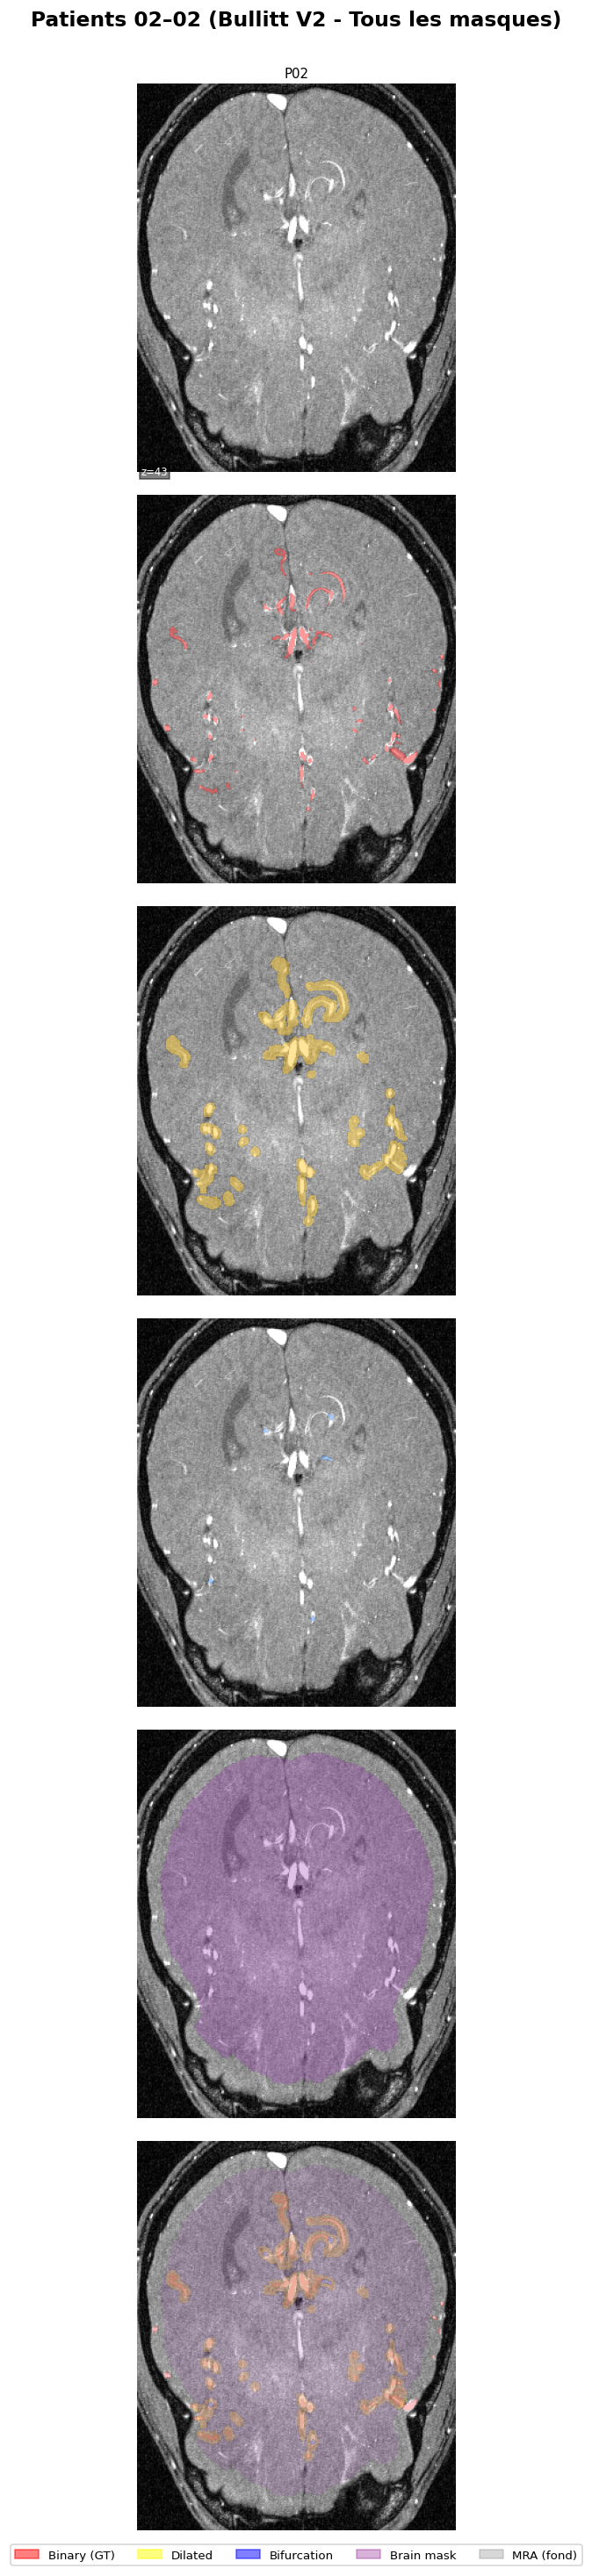


COMPARAISON DES TYPES DE MASQUES — PREMIER PATIENT

Comparaison des masques pour le patient 02 :


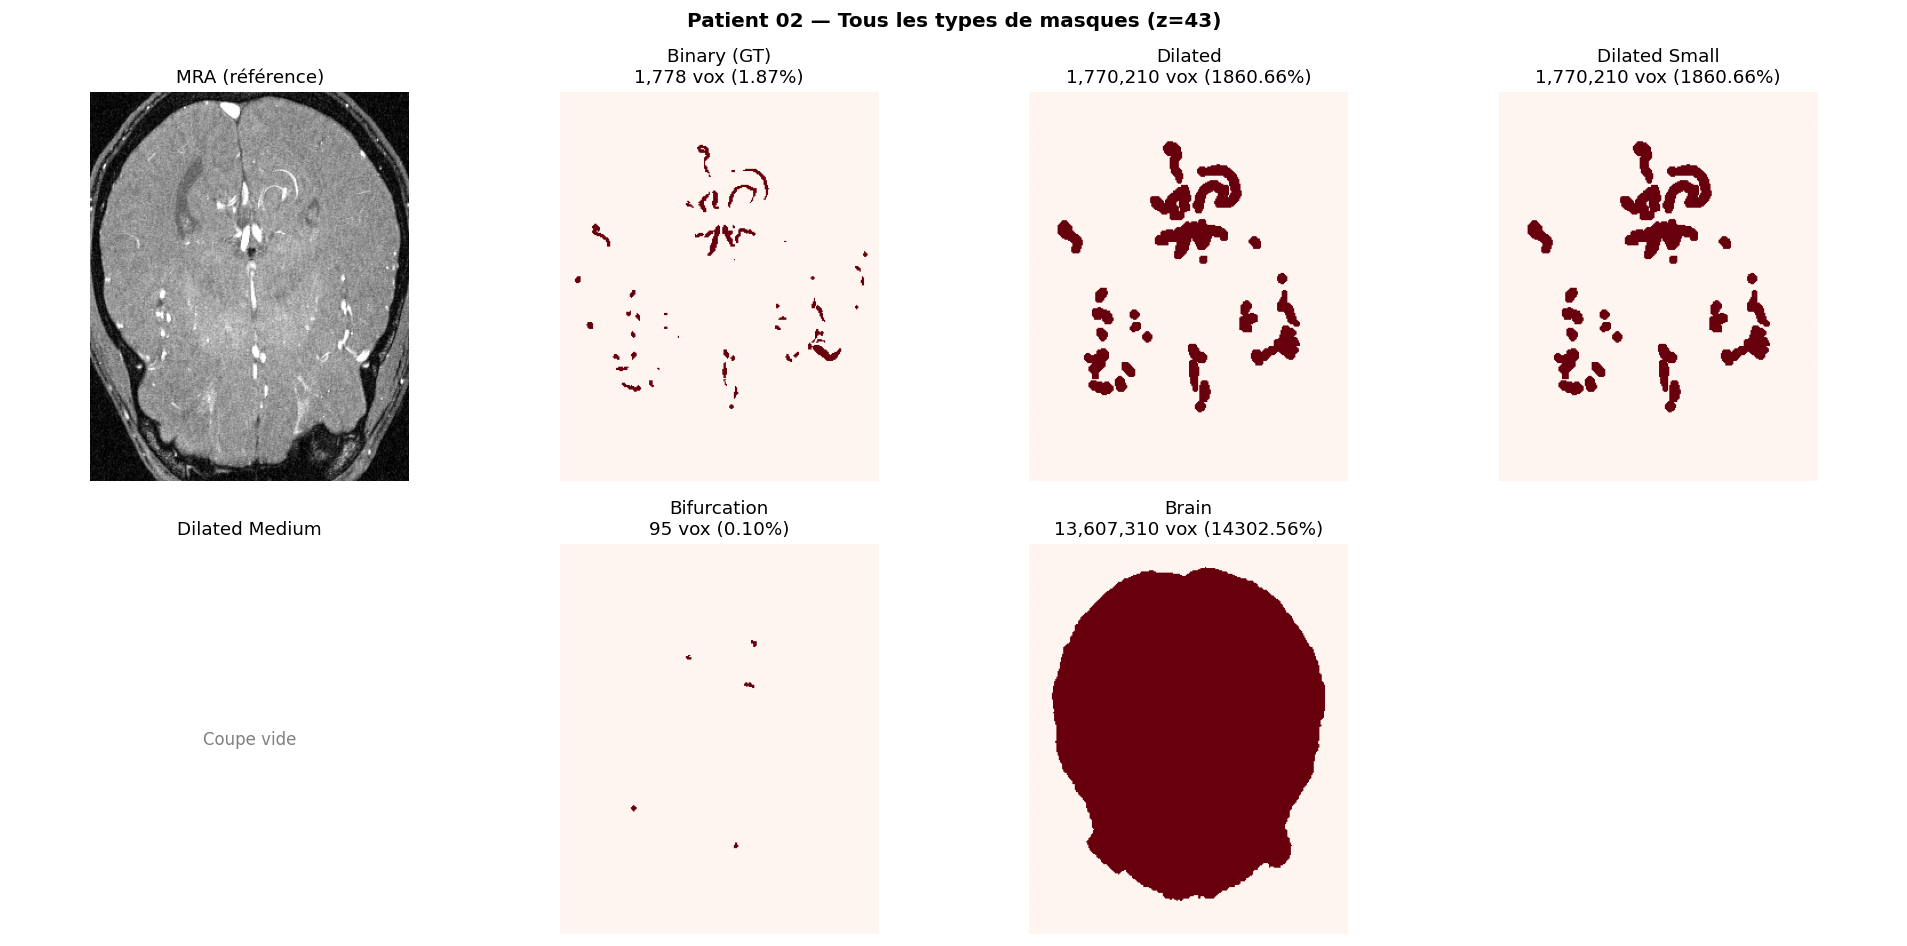

In [15]:
# =============================================================================
# GRILLE DE VISUALISATION — BULLITT V2 AVEC TOUS LES MASQUES
# =============================================================================

print("\n" + "=" * 60)
print("GRILLE DE VISUALISATION — PATIENTS BULLITT (TOUS LES MASQUES)")
print("=" * 60)

# ── Configuration ──────────────────────────────────────────────────────────
PATIENTS_PER_FIGURE = 5
N_ROWS = 6  # Augmenté pour inclure tous les types de masques

# Palettes de couleurs pour les différents types de masques
MASK_COLORS = {
    'binary': '#FF6B6B',           # Rouge
    'dilated': '#FFD93D',          # Jaune
    'dilated_small': '#FF9F43',    # Orange
    'dilated_medium': '#FF6B6B',   # Rouge clair
    'dilated_s': '#6BCB77',        # Vert
    'bifurcation': '#4D96FF',      # Bleu
    'brain': '#9B59B6',            # Violet
    'rician': '#A9A9A9',           # Gris
}

MASK_ALPHA = 0.5

# Fonction pour charger un masque spécifique
def load_specific_mask(patient_dir: Path, mask_type: str) -> Optional[np.ndarray]:
    """
    Charge un type spécifique de masque pour un patient.
    
    mask_type: 'binary', 'dilated', 'dilated_small', 'dilated_medium', 
               'dilated_s', 'bifurcation', 'brain', 'rician'
    """
    patterns = {
        'binary': ['binaryVesselsIso_S.nii.gz', 'binaryVesselsIso.nii.gz', 'binaryVesselsIso.nii'],
        'dilated': ['dilatedVesselsMask_S.nii.gz', 'dilatedVesselsMask.nii.gz', 'dilatedVesselsMask.nii'],
        'dilated_small': ['dilatedVesselsMaskSmall_S.nii.gz', 'dilatedVesselsMaskSmall.nii.gz', 'dilatedVesselsMaskSmall.nii'],
        'dilated_medium': ['dilatedVesselsMaskMedium_S.nii.gz', 'dilatedVesselsMaskMedium.nii.gz', 'dilatedVesselsMaskMedium.nii'],
        'dilated_s': ['dilatedVesselsMask_S.nii.gz', 'dilatedVesselsMask.nii.gz', 'dilatedVesselsMask.nii'],
        'bifurcation': ['bifurcationMaskIso_S.nii.gz', 'bifurcationMaskIso.nii.gz', 'bifurcationMaskIso.nii'],
        'brain': ['brainMaskIso.nii.gz', 'brainMaskIso.nii'],
        'rician': ['rician_4.0.nii.gz', 'rician_4.0.nii'],
    }
    
    for pattern in patterns.get(mask_type, []):
        mask_file = patient_dir / pattern
        if mask_file.exists():
            try:
                img = nib.load(str(mask_file))
                data = img.get_fdata(dtype=np.float32)
                return data
            except:
                continue
    return None

# Fenêtrage pour l'affichage des MRA
def get_window_params(data):
    p1, p99 = np.percentile(data, (1, 99))
    return p1, p99

# ── Création de la grille ──────────────────────────────────────────────────

# Récupération des IDs triés
pids_list = sorted([data["pid"] for data in dataset.values()])
n_patients = len(pids_list)
n_figures = (n_patients + PATIENTS_PER_FIGURE - 1) // PATIENTS_PER_FIGURE

ROW_LABELS = [
    '① MRA (fenêtrage adaptatif)',
    '② MRA + binary vessels (GT)',
    '③ MRA + dilated vessels',
    '④ MRA + bifurcation mask',
    '⑤ MRA + brain mask',
    '⑥ Masques superposés',
]

for fig_idx in range(n_figures):
    start_idx = fig_idx * PATIENTS_PER_FIGURE
    end_idx = min(start_idx + PATIENTS_PER_FIGURE, n_patients)
    pid_range = pids_list[start_idx:end_idx]
    n_cols = len(pid_range)
    
    fig, axes = plt.subplots(N_ROWS, n_cols, 
                              figsize=(4 * n_cols, 4 * N_ROWS))
    
    if n_cols == 1:
        axes = axes[:, np.newaxis]
    
    fig.suptitle(f'Patients {pid_range[0]:02d}–{pid_range[-1]:02d} (Bullitt V2 - Tous les masques)',
                 fontsize=14, fontweight='bold', y=1.002)
    
    for row, lbl in enumerate(ROW_LABELS):
        axes[row, 0].set_ylabel(lbl, fontsize=8, labelpad=6, fontweight='bold')
    
    for col_idx, pid in enumerate(pid_range):
        key = f"Normal{pid:03d}-MRA"
        data = dataset.get(key, {})
        mra = data.get("mra")
        
        # Dossier patient
        patient_dir = DATA_DIR / f"Normal{pid:03d}-MRA"
        
        # Titre du patient
        axes[0, col_idx].set_title(
            f'P{pid:02d}',
            fontsize=9, pad=4)
        
        if mra is None:
            for row in range(N_ROWS):
                axes[row, col_idx].text(0.5, 0.5, 'MRA\nmanquant',
                    ha='center', va='center', 
                    transform=axes[row, col_idx].transAxes,
                    fontsize=11, color='gray')
                axes[row, col_idx].axis('off')
            continue
        
        # Sélection de la coupe avec le plus de vaisseaux (GT)
        binary_mask = load_specific_mask(patient_dir, 'binary')
        if binary_mask is not None and binary_mask.sum() > 0:
            slice_vessel_counts = binary_mask.sum(axis=(0, 1))
            zc = int(np.argmax(slice_vessel_counts)) if slice_vessel_counts.max() > 0 else mra.shape[2] // 2
        else:
            zc = mra.shape[2] // 2
        
        zc = min(zc, mra.shape[2] - 1)
        
        # Extraction de la coupe 2D
        img2d = mra[:, :, zc] if mra.ndim == 3 else mra
        vmin, vmax = get_window_params(img2d)
        
        # Charger tous les masques
        masks = {
            'binary': load_specific_mask(patient_dir, 'binary'),
            'dilated': load_specific_mask(patient_dir, 'dilated'),
            'bifurcation': load_specific_mask(patient_dir, 'bifurcation'),
            'brain': load_specific_mask(patient_dir, 'brain'),
        }
        
        # Extraire les coupes 2D
        masks_2d = {}
        for name, mask_data in masks.items():
            if mask_data is not None and mask_data.shape[2] > zc:
                masks_2d[name] = mask_data[:, :, zc]
            else:
                masks_2d[name] = None
        
        # ── ① MRA brut ──────────────────────────────────────────────────
        ax = axes[0, col_idx]
        ax.imshow(img2d.T, cmap='gray', vmin=vmin, vmax=vmax, origin='lower')
        ax.text(3, 5, f'z={zc}', color='white', fontsize=7, va='top',
                bbox=dict(facecolor='black', alpha=0.5, pad=1))
        ax.axis('off')
        
        # ── ② MRA + binary vessels (GT) ──────────────────────────────
        ax = axes[1, col_idx]
        ax.imshow(img2d.T, cmap='gray', vmin=vmin, vmax=vmax, origin='lower')
        if masks_2d['binary'] is not None and masks_2d['binary'].sum() > 0:
            overlay = np.zeros((*masks_2d['binary'].T.shape, 4))
            overlay[masks_2d['binary'].T > 0] = [1, 0.2, 0.2, MASK_ALPHA]
            ax.imshow(overlay, origin='lower')
        ax.axis('off')
        
        # ── ③ MRA + dilated vessels ──────────────────────────────────
        ax = axes[2, col_idx]
        ax.imshow(img2d.T, cmap='gray', vmin=vmin, vmax=vmax, origin='lower')
        if masks_2d['dilated'] is not None and masks_2d['dilated'].sum() > 0:
            overlay = np.zeros((*masks_2d['dilated'].T.shape, 4))
            overlay[masks_2d['dilated'].T > 0] = [1, 0.8, 0.2, MASK_ALPHA]
            ax.imshow(overlay, origin='lower')
        ax.axis('off')
        
        # ── ④ MRA + bifurcation mask ──────────────────────────────────
        ax = axes[3, col_idx]
        ax.imshow(img2d.T, cmap='gray', vmin=vmin, vmax=vmax, origin='lower')
        if masks_2d['bifurcation'] is not None and masks_2d['bifurcation'].sum() > 0:
            overlay = np.zeros((*masks_2d['bifurcation'].T.shape, 4))
            overlay[masks_2d['bifurcation'].T > 0] = [0.3, 0.6, 1, MASK_ALPHA]
            ax.imshow(overlay, origin='lower')
        ax.axis('off')
        
        # ── ⑤ MRA + brain mask ────────────────────────────────────────
        ax = axes[4, col_idx]
        ax.imshow(img2d.T, cmap='gray', vmin=vmin, vmax=vmax, origin='lower')
        if masks_2d['brain'] is not None and masks_2d['brain'].sum() > 0:
            overlay = np.zeros((*masks_2d['brain'].T.shape, 4))
            overlay[masks_2d['brain'].T > 0] = [0.6, 0.2, 0.7, 0.3]
            ax.imshow(overlay, origin='lower')
        ax.axis('off')
        
        # ── ⑥ Tous les masques superposés ────────────────────────────
        ax = axes[5, col_idx]
        # Fond: MRA en gris
        ax.imshow(img2d.T, cmap='gray', vmin=vmin, vmax=vmax, origin='lower')
        
        # Superposer tous les masques avec des couleurs différentes
        # Binary: Rouge
        if masks_2d['binary'] is not None and masks_2d['binary'].sum() > 0:
            overlay = np.zeros((*masks_2d['binary'].T.shape, 4))
            overlay[masks_2d['binary'].T > 0] = [1, 0.2, 0.2, 0.3]
            ax.imshow(overlay, origin='lower')
        
        # Dilated: Jaune
        if masks_2d['dilated'] is not None and masks_2d['dilated'].sum() > 0:
            overlay = np.zeros((*masks_2d['dilated'].T.shape, 4))
            overlay[masks_2d['dilated'].T > 0] = [1, 0.8, 0.2, 0.3]
            ax.imshow(overlay, origin='lower')
        
        # Bifurcation: Bleu
        if masks_2d['bifurcation'] is not None and masks_2d['bifurcation'].sum() > 0:
            overlay = np.zeros((*masks_2d['bifurcation'].T.shape, 4))
            overlay[masks_2d['bifurcation'].T > 0] = [0.3, 0.6, 1, 0.5]
            ax.imshow(overlay, origin='lower')
        
        # Brain: Violet
        if masks_2d['brain'] is not None and masks_2d['brain'].sum() > 0:
            overlay = np.zeros((*masks_2d['brain'].T.shape, 4))
            overlay[masks_2d['brain'].T > 0] = [0.6, 0.2, 0.7, 0.15]
            ax.imshow(overlay, origin='lower')
        
        ax.axis('off')
    
    # Légende
    patches = [
        mpatches.Patch(color='red', alpha=0.5, label='Binary (GT)'),
        mpatches.Patch(color='yellow', alpha=0.5, label='Dilated'),
        mpatches.Patch(color='blue', alpha=0.5, label='Bifurcation'),
        mpatches.Patch(color='purple', alpha=0.3, label='Brain mask'),
        mpatches.Patch(color='gray', alpha=0.3, label='MRA (fond)'),
    ]
    fig.legend(handles=patches, loc='lower center', ncol=5, fontsize=8,
               frameon=True, bbox_to_anchor=(0.5, -0.01))
    
    plt.tight_layout()
    plt.savefig(f'fig_bullitt_grid_all_masks_{fig_idx+1}.png', bbox_inches='tight', dpi=110)
    plt.show()


# =============================================================================
# GRILLE DÉTAILLÉE — COMPARAISON DES MASQUES POUR UN PATIENT
# =============================================================================

print("\n" + "=" * 60)
print("COMPARAISON DES TYPES DE MASQUES — PREMIER PATIENT")
print("=" * 60)

def plot_all_masks_for_patient(pid: int):
    """
    Affiche tous les types de masques disponibles pour un patient.
    """
    patient_dir = DATA_DIR / f"Normal{pid:03d}-MRA"
    key = f"Normal{pid:03d}-MRA"
    data = dataset.get(key, {})
    mra = data.get("mra")
    
    if mra is None:
        print(f"  ⚠ Patient {pid} : MRA absent")
        return
    
    # Charger tous les masques
    mask_types = {
        'Binary (GT)': load_specific_mask(patient_dir, 'binary'),
        'Dilated': load_specific_mask(patient_dir, 'dilated'),
        'Dilated Small': load_specific_mask(patient_dir, 'dilated_small'),
        'Dilated Medium': load_specific_mask(patient_dir, 'dilated_medium'),
        'Bifurcation': load_specific_mask(patient_dir, 'bifurcation'),
        'Brain': load_specific_mask(patient_dir, 'brain'),
        'Rician': load_specific_mask(patient_dir, 'rician'),
    }
    
    # Sélection de la coupe
    binary_mask = mask_types['Binary (GT)']
    if binary_mask is not None and binary_mask.sum() > 0:
        zc = int(np.argmax(binary_mask.sum(axis=(0, 1))))
    else:
        zc = mra.shape[2] // 2
    
    zc = min(zc, mra.shape[2] - 1)
    img2d = mra[:, :, zc] if mra.ndim == 3 else mra
    vmin, vmax = get_window_params(img2d)
    
    # Filtrer les masques présents
    present_masks = {name: mask for name, mask in mask_types.items() if mask is not None}
    n_masks = len(present_masks)
    
    if n_masks == 0:
        print(f"  ⚠ Patient {pid} : Aucun masque trouvé")
        return
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle(f'Patient {pid:02d} — Tous les types de masques (z={zc})', 
                 fontsize=12, fontweight='bold')
    
    # MRA de référence
    ax = axes[0, 0]
    ax.imshow(img2d.T, cmap='gray', vmin=vmin, vmax=vmax, origin='lower')
    ax.set_title('MRA (référence)')
    ax.axis('off')
    
    # Afficher chaque masque
    for idx, (name, mask_data) in enumerate(present_masks.items()):
        row = (idx + 1) // 4
        col = (idx + 1) % 4
        
        if row < 2 and col < 4:
            ax = axes[row, col]
            mask_2d = mask_data[:, :, zc] if mask_data.shape[2] > zc else None
            
            if mask_2d is not None and mask_2d.sum() > 0:
                ax.imshow(mask_2d.T, cmap='Reds', origin='lower')
                n_vox = int(mask_2d.sum())
                ratio = 100 * n_vox / mask_2d.size
                ax.set_title(f'{name}\n{n_vox:,} vox ({ratio:.2f}%)')
            else:
                ax.text(0.5, 0.5, 'Coupe vide', ha='center', va='center',
                       transform=ax.transAxes, fontsize=10, color='gray')
                ax.set_title(name)
            ax.axis('off')
    
    # Cacher les axes vides
    for idx in range(len(present_masks) + 1, 8):
        row = idx // 4
        col = idx % 4
        if row < 2 and col < 4:
            axes[row, col].axis('off')
    
    plt.tight_layout()
    plt.show()

# Affichage pour le premier patient
if pids_list:
    print(f"\nComparaison des masques pour le patient {pids_list[0]:02d} :")
    plot_all_masks_for_patient(pids_list[0])

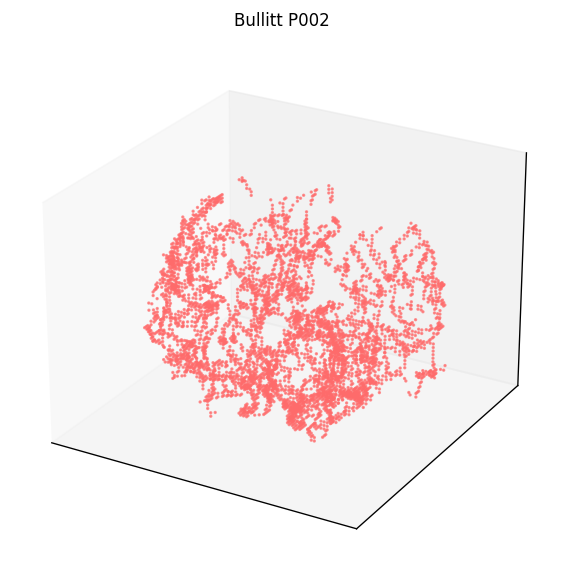

In [17]:
## 3D Bullitt — Petit format pour l'article

def show_bullitt_3d_small(pid: int, step: int = 3):
    """
    Petite visualisation 3D Bullitt pour l'article.
    """
    key = f"Normal{pid:03d}-MRA"
    data = dataset.get(key, {})
    mra = data.get("mra")
    
    if mra is None:
        print(f"P{pid}: MRA absent")
        return None
    
    patient_dir = DATA_DIR / f"Normal{pid:03d}-MRA"
    binary_mask = load_specific_mask(patient_dir, 'binary')
    
    if binary_mask is None:
        print(f"P{pid}: Masque absent")
        return None
    
    # Sous-échantillonnage
    binary_sub = binary_mask[::step, ::step, ::step] > 0
    brain_mask = load_specific_mask(patient_dir, 'brain')
    brain_sub = brain_mask[::step, ::step, ::step] > 0 if brain_mask is not None else None
    
    fig = plt.figure(figsize=(5, 5))
    ax = fig.add_subplot(111, projection='3d')
    
    # Cerveau
    if brain_sub is not None and brain_sub.sum() > 0:
        try:
            verts, faces, _, _ = marching_cubes(brain_sub, level=0.5)
            ax.plot_trisurf(verts[:, 0], verts[:, 1], faces, verts[:, 2],
                            color='#9B59B6', alpha=0.08, edgecolor='none')
        except:
            pass
    
    # Vaisseaux
    pts = np.where(binary_sub > 0)
    if len(pts[0]) > 0:
        n_pts = len(pts[0])
        if n_pts > 8000:
            idx = np.random.choice(n_pts, 8000, replace=False)
            pts = (pts[0][idx], pts[1][idx], pts[2][idx])
        ax.scatter(pts[0], pts[1], pts[2],
                   c='#FF6B6B', s=1.0, alpha=0.7)
    
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    ax.set_xlabel(''); ax.set_ylabel(''); ax.set_zlabel('')
    ax.view_init(elev=25, azim=-60)
    ax.set_title(f'Bullitt P{pid:03d}', fontsize=10)
    
    plt.tight_layout()
    return fig

# ── Exécution ──────────────────────────────────────────────────────────────
best_pid = pids_list[0] if pids_list else None
fig = show_bullitt_3d_small(best_pid, step=3)
if fig:
    plt.savefig(f'fig_3d_bullitt_small_P{best_pid:03d}.png', 
                bbox_inches='tight', dpi=120)
    plt.show()


COMPARAISON DES RATIOS VASCULAIRES


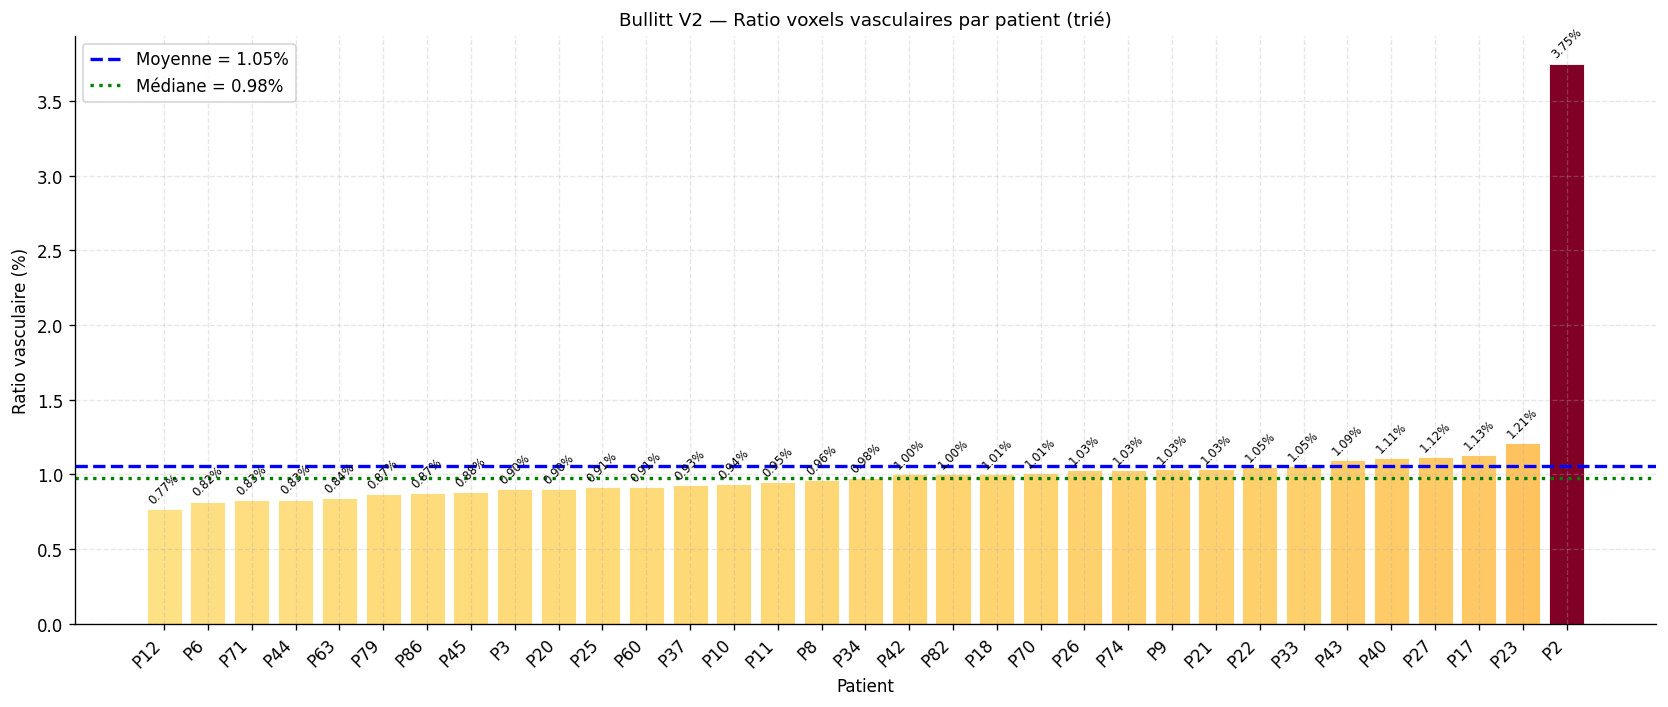


Statistiques des ratios vasculaires :
  Moyenne : 1.054%
  Médiane : 0.979%
  Écart-type : 0.488%
  Min / Max : 0.769% / 3.752%


In [ ]:
# =============================================================================
# GRILLE COMPARATIVE — RATIO VASCULAIRE PAR PATIENT (VERSION ROBUSTE)
# =============================================================================

print("\n" + "=" * 60)
print("COMPARAISON DES RATIOS VASCULAIRES")
print("=" * 60)

if "vessel_ratio_pct" in df_summary.columns:
    valid = df_summary[df_summary["vessel_ratio_pct"].notna()]
    
    if not valid.empty:
        fig, ax = plt.subplots(figsize=(14, 6))
        
        # Extraction des données
        valid_sorted = valid.sort_values("vessel_ratio_pct")
        pids = valid_sorted.index.tolist()
        ratios_array = valid_sorted["vessel_ratio_pct"].values  # numpy array
        
        # Couleurs
        colors = plt.cm.YlOrRd(ratios_array / ratios_array.max())
        
        # Barres
        bars = ax.bar(range(len(valid_sorted)), ratios_array, color=colors, 
                      edgecolor='white', linewidth=0.5)
        
        # Statistiques avec numpy (fonctionne toujours)
        mean_ratio = np.mean(ratios_array)
        median_ratio = np.median(ratios_array)
        
        # Lignes de référence
        ax.axhline(mean_ratio, color='blue', linestyle='--', 
                   linewidth=2, label=f'Moyenne = {mean_ratio:.2f}%')
        ax.axhline(median_ratio, color='green', linestyle=':', 
                   linewidth=2, label=f'Médiane = {median_ratio:.2f}%')
        
        # Annotations
        for i, (pid, ratio) in enumerate(zip(pids, ratios_array)):
            ax.text(i, ratio + 0.02, f'{ratio:.2f}%', 
                   ha='center', va='bottom', fontsize=7, rotation=45)
        
        ax.set_xlabel('Patient')
        ax.set_ylabel('Ratio vasculaire (%)')
        ax.set_title('Bullitt V2 — Ratio voxels vasculaires par patient (trié)')
        ax.set_xticks(range(len(valid_sorted)))
        ax.set_xticklabels([f'P{p}' for p in pids], rotation=45, ha='right')
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        plt.savefig('fig_bullitt_ratios_sorted.png', bbox_inches='tight', dpi=120)
        plt.show()
        
        # Affichage des statistiques
        print(f"\nStatistiques des ratios vasculaires :")
        print(f"  Moyenne : {mean_ratio:.3f}%")
        print(f"  Médiane : {median_ratio:.3f}%")
        print(f"  Écart-type : {np.std(ratios_array):.3f}%")
        print(f"  Min / Max : {np.min(ratios_array):.3f}% / {np.max(ratios_array):.3f}%")

In [ ]:
# =============================================================================
# TABLEAU DÉTAILLÉ DES CARACTÉRISTIQUES — BULLITT V2 (TOUS LES MASQUES)
# =============================================================================

print("\n" + "=" * 80)
print("TABLEAU DÉTAILLÉ DES CARACTÉRISTIQUES — BULLITT V2")
print("=" * 80)

# ── Définition des types de masques ──────────────────────────────────────

MASK_TYPES = {
    'binary': {
        'pattern': ['binaryVesselsIso_S.nii.gz', 'binaryVesselsIso.nii.gz', 'binaryVesselsIso.nii'],
        'label': 'Binary (GT)',
        'color': '#FF6B6B'
    },
    'dilated': {
        'pattern': ['dilatedVesselsMask_S.nii.gz', 'dilatedVesselsMask.nii.gz', 'dilatedVesselsMask.nii'],
        'label': 'Dilated',
        'color': '#FFD93D'
    },
    'dilated_small': {
        'pattern': ['dilatedVesselsMaskSmall_S.nii.gz', 'dilatedVesselsMaskSmall.nii.gz', 'dilatedVesselsMaskSmall.nii'],
        'label': 'Dilated Small',
        'color': '#FF9F43'
    },
    'dilated_medium': {
        'pattern': ['dilatedVesselsMaskMedium_S.nii.gz', 'dilatedVesselsMaskMedium.nii.gz', 'dilatedVesselsMaskMedium.nii'],
        'label': 'Dilated Medium',
        'color': '#FF6B6B'
    },
    'bifurcation': {
        'pattern': ['bifurcationMaskIso_S.nii.gz', 'bifurcationMaskIso.nii.gz', 'bifurcationMaskIso.nii'],
        'label': 'Bifurcation',
        'color': '#4D96FF'
    },
    'brain': {
        'pattern': ['brainMaskIso.nii.gz', 'brainMaskIso.nii'],
        'label': 'Brain Mask',
        'color': '#9B59B6'
    },
    'rician': {
        'pattern': ['rician_4.0.nii.gz', 'rician_4.0.nii'],
        'label': 'Rician Noise',
        'color': '#A9A9A9'
    }
}

# ── Fonction pour charger un masque spécifique ───────────────────────────

def load_mask_by_type(patient_dir: Path, mask_type: str) -> Optional[np.ndarray]:
    """Charge un type spécifique de masque pour un patient."""
    patterns = MASK_TYPES.get(mask_type, {}).get('pattern', [])
    for pattern in patterns:
        mask_file = patient_dir / pattern
        if mask_file.exists():
            try:
                img = nib.load(str(mask_file))
                data = img.get_fdata(dtype=np.float32)
                return data
            except:
                continue
    return None

def compute_mask_stats_from_data(mask_data: np.ndarray, spacing: tuple) -> Dict:
    """Calcule les statistiques d'un masque à partir des données chargées."""
    if mask_data is None or mask_data.size == 0:
        return {
            "voxels": 0,
            "ratio_pct": 0.0,
            "n_components": 0,
            "slice_coverage": 0,
            "slice_coverage_pct": 0.0,
            "volume_cm3": 0.0,
            "bbox_volume_cm3": 0.0,
            "bbox_density_pct": 0.0,
        }
    
    binary = mask_data > 0
    n_vox = binary.size
    n_fg = int(binary.sum())
    ratio_pct = 100 * n_fg / n_vox if n_vox > 0 else 0.0
    
    # Composantes connexes
    from scipy.ndimage import label
    labeled, n_cc = label(binary)
    
    # Couverture en slices
    slice_coverage = int((binary.sum(axis=(0, 1)) > 0).sum())
    slice_coverage_pct = 100 * slice_coverage / mask_data.shape[2] if mask_data.shape[2] > 0 else 0.0
    
    # Volume en cm³
    sx, sy, sz = spacing[:3]
    volume_cm3 = n_fg * sx * sy * sz / 1000
    
    # Bbox
    coords = np.where(binary)
    if len(coords[0]) > 0:
        bbox = (
            (int(coords[0].min()), int(coords[0].max())),
            (int(coords[1].min()), int(coords[1].max())),
            (int(coords[2].min()), int(coords[2].max())),
        )
        bbox_size = (
            bbox[0][1] - bbox[0][0] + 1,
            bbox[1][1] - bbox[1][0] + 1,
            bbox[2][1] - bbox[2][0] + 1,
        )
        bbox_volume_voxels = bbox_size[0] * bbox_size[1] * bbox_size[2]
        bbox_volume_cm3 = bbox_volume_voxels * sx * sy * sz / 1000
        bbox_density_pct = 100 * n_fg / bbox_volume_voxels if bbox_volume_voxels > 0 else 0.0
    else:
        bbox_volume_cm3 = 0.0
        bbox_density_pct = 0.0
    
    return {
        "voxels": n_fg,
        "ratio_pct": round(ratio_pct, 3),
        "n_components": n_cc,
        "slice_coverage": slice_coverage,
        "slice_coverage_pct": round(slice_coverage_pct, 1),
        "volume_cm3": round(volume_cm3, 4),
        "bbox_volume_cm3": round(bbox_volume_cm3, 4),
        "bbox_density_pct": round(bbox_density_pct, 2),
    }

# ── Construction du tableau détaillé ──────────────────────────────────────

detailed_rows = []

for pid in pids_list:
    key = f"Normal{pid:03d}-MRA"
    data = dataset.get(key, {})
    patient_dir = DATA_DIR / f"Normal{pid:03d}-MRA"
    
    # Métadonnées MRA
    mra = data.get("mra")
    spacing = (0.5134, 0.5134, 0.5134)  # Spacing isotrope
    
    # Dimensions
    if mra is not None:
        shape = mra.shape
        n_voxels_total = np.prod(shape)
        size_mm = (shape[0] * spacing[0], shape[1] * spacing[1], shape[2] * spacing[2])
        volume_total_cm3 = n_voxels_total * spacing[0] * spacing[1] * spacing[2] / 1000
    else:
        shape = (0, 0, 0)
        n_voxels_total = 0
        size_mm = (0, 0, 0)
        volume_total_cm3 = 0.0
    
    # Charger TOUS les types de masques
    mask_stats_all = {}
    for mask_type in MASK_TYPES:
        mask_data = load_mask_by_type(patient_dir, mask_type)
        if mask_data is not None:
            mask_stats_all[mask_type] = compute_mask_stats_from_data(mask_data, spacing)
        else:
            mask_stats_all[mask_type] = None
    
    # Construction de la ligne
    row = {
        "patient": pid,
        # Dimensions
        "shape_x": shape[0] if len(shape) > 0 else 0,
        "shape_y": shape[1] if len(shape) > 1 else 0,
        "shape_z": shape[2] if len(shape) > 2 else 0,
        "size_x_mm": round(size_mm[0], 1),
        "size_y_mm": round(size_mm[1], 1),
        "size_z_mm": round(size_mm[2], 1),
        "volume_total_cm3": round(volume_total_cm3, 2),
        "mra_present": mra is not None,
    }
    
    # Ajouter les statistiques pour chaque type de masque
    for mask_type, stats in mask_stats_all.items():
        label = MASK_TYPES[mask_type]['label']
        if stats is not None:
            row[f"{mask_type}_present"] = True
            row[f"{mask_type}_voxels"] = stats["voxels"]
            row[f"{mask_type}_ratio_pct"] = stats["ratio_pct"]
            row[f"{mask_type}_n_components"] = stats["n_components"]
            row[f"{mask_type}_slice_coverage"] = stats["slice_coverage"]
            row[f"{mask_type}_slice_coverage_pct"] = stats["slice_coverage_pct"]
            row[f"{mask_type}_volume_cm3"] = stats["volume_cm3"]
            row[f"{mask_type}_bbox_volume_cm3"] = stats["bbox_volume_cm3"]
            row[f"{mask_type}_bbox_density_pct"] = stats["bbox_density_pct"]
        else:
            row[f"{mask_type}_present"] = False
            row[f"{mask_type}_voxels"] = 0
            row[f"{mask_type}_ratio_pct"] = np.nan
            row[f"{mask_type}_n_components"] = np.nan
            row[f"{mask_type}_slice_coverage"] = np.nan
            row[f"{mask_type}_slice_coverage_pct"] = np.nan
            row[f"{mask_type}_volume_cm3"] = np.nan
            row[f"{mask_type}_bbox_volume_cm3"] = np.nan
            row[f"{mask_type}_bbox_density_pct"] = np.nan
    
    detailed_rows.append(row)

df_detailed = pd.DataFrame(detailed_rows).set_index("patient")

# ── Affichage du tableau détaillé ─────────────────────────────────────────

print("\n" + "=" * 80)
print("TABLEAU DÉTAILLÉ — TOUS LES TYPES DE MASQUES")
print("=" * 80)

# Colonnes pour l'affichage
base_cols = ['shape_x', 'shape_y', 'shape_z', 'size_x_mm', 'size_y_mm', 'size_z_mm', 'volume_total_cm3']

# Colonnes pour chaque type de masque
mask_cols = []
for mask_type in MASK_TYPES:
    label = MASK_TYPES[mask_type]['label']
    mask_cols.extend([
        f"{mask_type}_present",
        f"{mask_type}_voxels",
        f"{mask_type}_ratio_pct",
        f"{mask_type}_n_components",
        f"{mask_type}_volume_cm3",
    ])

display_cols = base_cols + mask_cols
display_cols = [c for c in display_cols if c in df_detailed.columns]

# Style pour la colonne "present"
def color_present(val):
    if isinstance(val, bool):
        return 'background-color:#d4edda; color:#155724' if val else 'background-color:#f8d7da; color:#721c24'
    return ''

display(
    df_detailed[display_cols].style
    .applymap(color_present, subset=[c for c in display_cols if c.endswith('_present')])
    .background_gradient(subset=['binary_ratio_pct', 'dilated_ratio_pct'], cmap='Blues')
    .background_gradient(subset=['binary_n_components', 'dilated_n_components'], cmap='Oranges')
    .format({
        'size_x_mm': '{:.1f}',
        'size_y_mm': '{:.1f}',
        'size_z_mm': '{:.1f}',
        'volume_total_cm3': '{:.2f}',
        'binary_voxels': '{:,}',
        'dilated_voxels': '{:,}',
        'binary_ratio_pct': '{:.2f}',
        'dilated_ratio_pct': '{:.2f}',
        'binary_volume_cm3': '{:.4f}',
        'dilated_volume_cm3': '{:.4f}',
        'binary_n_components': '{:.0f}',
        'dilated_n_components': '{:.0f}',
    }, na_rep='—')
)

# ── Résumé par type de masque ─────────────────────────────────────────────

print("\n" + "=" * 80)
print("RÉSUMÉ PAR TYPE DE MASQUE")
print("=" * 80)

for mask_type, info in MASK_TYPES.items():
    label = info['label']
    present = df_detailed[f"{mask_type}_present"].sum()
    if present > 0:
        ratios = df_detailed[df_detailed[f"{mask_type}_present"]][f"{mask_type}_ratio_pct"].dropna()
        voxels = df_detailed[df_detailed[f"{mask_type}_present"]][f"{mask_type}_voxels"].dropna()
        comps = df_detailed[df_detailed[f"{mask_type}_present"]][f"{mask_type}_n_components"].dropna()
        
        print(f"\n  📋 {label} ({info['color']})")
        print(f"  ────────────────────────────────────")
        print(f"    Présent chez : {present}/{len(df_detailed)} patients")
        if not ratios.empty:
            print(f"    Ratio moyen   : {ratios.mean():.3f}% (min={ratios.min():.3f}%, max={ratios.max():.3f}%)")
            print(f"    Voxels moyen  : {voxels.mean():,.0f} (min={voxels.min():,}, max={voxels.max():,})")
            print(f"    Composantes   : {comps.mean():.1f} (min={comps.min():.0f}, max={comps.max():.0f})")
    else:
        print(f"\n  📋 {label} : ❌ Aucun patient")

# ── Statistiques globales ──────────────────────────────────────────────────

print("\n" + "=" * 80)
print("STATISTIQUES GLOBALES — TOUS LES MASQUES")
print("=" * 80)

print(f"\n   STATISTIQUES GÉNÉRALES")
print(f"  ───────────────────────")
print(f"  Patients totaux            : {len(df_detailed)}")
print(f"  Patients avec MRA          : {df_detailed['mra_present'].sum()}")

print(f"\n   GÉOMÉTRIE")
print(f"  ───────────")
print(f"  Taille moyenne (voxels)    : {df_detailed['shape_x'].mean():.0f} × {df_detailed['shape_y'].mean():.0f} × {df_detailed['shape_z'].mean():.0f}")
print(f"  Volume moyen (cm³)         : {df_detailed['volume_total_cm3'].mean():.2f}")

print(f"\n   DISPONIBILITÉ DES MASQUES")
print(f"  ──────────────────────────")
for mask_type, info in MASK_TYPES.items():
    present = df_detailed[f"{mask_type}_present"].sum()
    pct = 100 * present / len(df_detailed)
    print(f"  {info['label']:<20} : {present:>2}/{len(df_detailed)} ({pct:.1f}%)")

print(f"\n Analyse terminée.")


TABLEAU DÉTAILLÉ DES CARACTÉRISTIQUES — BULLITT V2

TABLEAU DÉTAILLÉ — TOUS LES TYPES DE MASQUES


,shape_x,shape_y,shape_z,size_x_mm,size_y_mm,size_z_mm,volume_total_cm3,binary_present,binary_voxels,binary_ratio_pct,binary_n_components,binary_volume_cm3,dilated_present,dilated_voxels,dilated_ratio_pct,dilated_n_components,dilated_volume_cm3,dilated_small_present,dilated_small_voxels,dilated_small_ratio_pct,dilated_small_n_components,dilated_small_volume_cm3,dilated_medium_present,dilated_medium_voxels,dilated_medium_ratio_pct,dilated_medium_n_components,dilated_medium_volume_cm3,bifurcation_present,bifurcation_voxels,bifurcation_ratio_pct,bifurcation_n_components,bifurcation_volume_cm3,brain_present,brain_voxels,brain_ratio_pct,brain_n_components,brain_volume_cm3,rician_present,rician_voxels,rician_ratio_pct,rician_n_components,rician_volume_cm3
patient,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2,279,341,178,143.2,175.1,91.4,2291.64,True,"144,060",0.85,21,19.4945,True,"763,838",4.51,49,103.3639,True,724979,4.281000,52,98.105400,True,38859,0.229000,5,5.258500,True,9482,0.056000,110,1.283100,True,7364927,43.490000,1,996.634800,True,16811269,99.271000,1,2274.930300
3,277,341,178,142.2,175.1,91.4,2275.21,True,"151,846",0.90,65,20.5481,True,"835,850",4.97,52,113.1087,True,803980,4.782000,59,108.796000,True,31870,0.190000,5,4.312700,True,10298,0.061000,128,1.393500,True,6989906,41.574000,1,945.886300,True,16675708,99.181000,1,2256.585900
6,281,361,170,144.3,185.3,87.3,2333.62,True,"141,075",0.82,50,19.0905,True,"773,698",4.49,46,104.6982,True,740648,4.295000,50,100.225800,True,33050,0.192000,8,4.472400,True,9358,0.054000,103,1.266300,True,7703197,44.669000,1,1042.410100,True,17112990,99.235000,1,2315.759700
8,271,351,176,139.1,180.2,90.4,2265.46,True,"161,380",0.96,71,21.8382,True,"879,216",5.25,45,118.9770,True,824068,4.922000,47,111.514300,True,55148,0.329000,5,7.462700,True,12744,0.076000,141,1.724500,True,7448903,44.494000,2,1007.998600,True,16614154,99.241000,1,2248.256300
9,275,355,180,141.2,182.3,92.4,2377.94,True,"181,664",1.03,61,24.5831,True,"984,334",5.60,82,133.2018,True,964685,5.490000,83,130.542900,True,19649,0.112000,4,2.658900,True,13283,0.076000,155,1.797500,True,7736131,44.024000,3,1046.866800,True,17422991,99.149000,1,2357.709600
10,273,369,182,140.2,189.4,93.4,2481.01,True,"171,958",0.94,37,23.2697,True,"952,299",5.19,63,128.8668,True,912929,4.979000,66,123.539100,True,39370,0.215000,4,5.327600,True,13076,0.071000,141,1.769500,True,8576757,46.780000,2,1160.621700,True,18192032,99.225000,1,2461.777500
11,275,337,178,141.2,173.0,91.4,2232.29,True,"156,182",0.95,45,21.1348,True,"816,794",4.95,40,110.5300,True,816794,4.951000,40,110.530000,True,0,0.000000,0,0.000000,True,10164,0.062000,117,1.375400,True,7038372,42.667000,1,952.444800,True,16334961,99.023000,1,2210.475400
12,285,363,178,146.3,186.4,91.4,2491.95,True,"141,688",0.77,67,19.1735,True,"853,671",4.64,43,115.5203,True,781875,4.246000,50,105.804700,True,71796,0.390000,10,9.715600,True,9699,0.053000,124,1.312500,True,8297038,45.056000,6,1122.769700,True,18274546,99.237000,1,2472.943500
17,269,341,166,138.1,175.1,85.2,2060.55,True,"172,064",1.13,84,23.2840,True,"958,318",6.29,62,129.6813,True,904594,5.941000,63,122.411200,True,53724,0.353000,5,7.270000,True,13110,0.086000,163,1.774100,True,6908229,45.368000,13,934.833600,True,15124909,99.329000,1,2046.729100



RÉSUMÉ PAR TYPE DE MASQUE

  📋 Binary (GT) (#FF6B6B)
  ────────────────────────────────────
    Présent chez : 33/33 patients
    Ratio moyen   : 0.966% (min=0.769%, max=1.212%)
    Voxels moyen  : 164,653 (min=138,980, max=193,911)
    Composantes   : 51.1 (min=21, max=106)

  📋 Dilated (#FFD93D)
  ────────────────────────────────────
    Présent chez : 33/33 patients
    Ratio moyen   : 5.062% (min=4.129%, max=6.594%)
    Voxels moyen  : 862,628 (min=723,196, max=1,021,623)
    Composantes   : 54.1 (min=27, max=86)

  📋 Dilated Small (#FF9F43)
  ────────────────────────────────────
    Présent chez : 33/33 patients
    Ratio moyen   : 4.692% (min=3.708%, max=6.230%)
    Voxels moyen  : 798,412 (min=634,731, max=964,685)
    Composantes   : 62.2 (min=40, max=96)

  📋 Dilated Medium (#FF6B6B)
  ────────────────────────────────────
    Présent chez : 33/33 patients
    Ratio moyen   : 0.370% (min=0.000%, max=1.102%)
    Voxels moyen  : 64,217 (min=0, max=197,963)
    Composantes   : 7.


VISUALISATION DES CARACTÉRISTIQUES — BULLITT V2


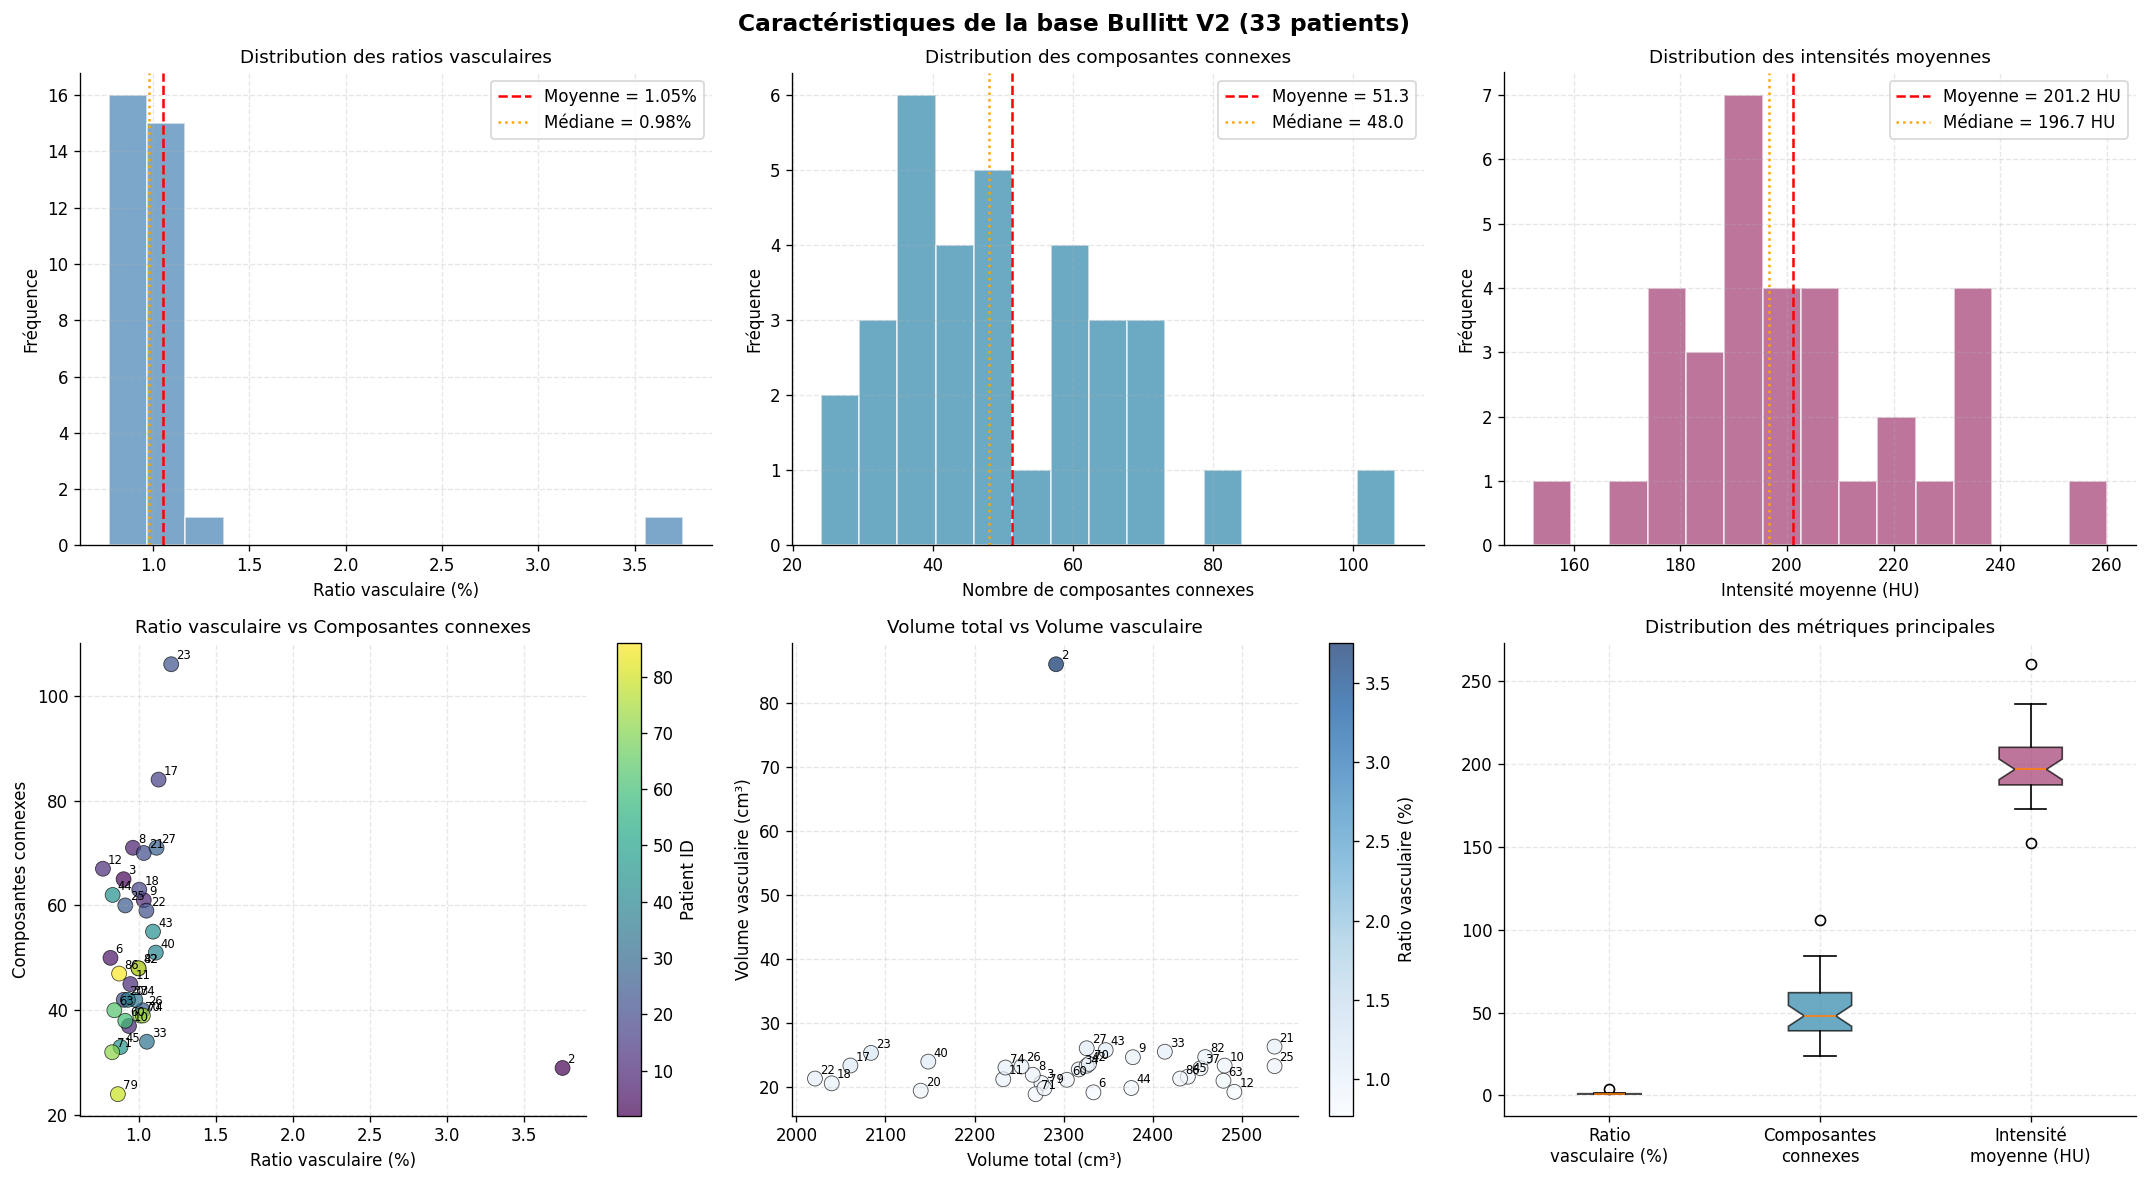


TABLEAU RÉCAPITULATIF DES STATISTIQUES


,Métrique,Valeur
0,Nombre de patients,33
1,Spacing (mm),0.5134 (isotrope)
2,Taille moyenne (voxels),273 × 351 × 178
3,Taille moyenne (mm),140.2 × 180.4 × 91.5
4,Volume moyen (cm³),"2,313.7"
5,Ratio vasculaire moyen (%),1.054
6,Ratio vasculaire médian (%),0.979
7,Ratio vasculaire min/max (%),0.769 / 3.752
8,Composantes connexes (moyenne),51.3
9,Composantes connexes (min/max),24 / 106


In [ ]:
# =============================================================================
# VISUALISATION DES CARACTÉRISTIQUES — BULLITT V2
# =============================================================================

print("\n" + "=" * 80)
print("VISUALISATION DES CARACTÉRISTIQUES — BULLITT V2")
print("=" * 80)

# ── Configuration du style ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Caractéristiques de la base Bullitt V2 (33 patients)', 
             fontsize=14, fontweight='bold')

# ── 1. Distribution des ratios vasculaires ──────────────────────────────
ax = axes[0, 0]
ratios = df_detailed["vessel_ratio_pct"].dropna()
ax.hist(ratios, bins=15, color='steelblue', edgecolor='white', alpha=0.7)
ax.axvline(ratios.mean(), color='red', linestyle='--', 
           label=f'Moyenne = {ratios.mean():.2f}%')
ax.axvline(ratios.median(), color='orange', linestyle=':', 
           label=f'Médiane = {ratios.median():.2f}%')
ax.set_xlabel('Ratio vasculaire (%)')
ax.set_ylabel('Fréquence')
ax.set_title('Distribution des ratios vasculaires')
ax.legend()
ax.grid(True, alpha=0.3)

# ── 2. Distribution des composantes connexes ────────────────────────────
ax = axes[0, 1]
comps = df_detailed["n_components"].dropna()
ax.hist(comps, bins=15, color='#2E86AB', edgecolor='white', alpha=0.7)
ax.axvline(comps.mean(), color='red', linestyle='--', 
           label=f'Moyenne = {comps.mean():.1f}')
ax.axvline(comps.median(), color='orange', linestyle=':', 
           label=f'Médiane = {comps.median():.1f}')
ax.set_xlabel('Nombre de composantes connexes')
ax.set_ylabel('Fréquence')
ax.set_title('Distribution des composantes connexes')
ax.legend()
ax.grid(True, alpha=0.3)

# ── 3. Distribution des intensités moyennes ──────────────────────────────
ax = axes[0, 2]
intens = df_detailed["intensity_mean"].dropna()
ax.hist(intens, bins=15, color='#A23B72', edgecolor='white', alpha=0.7)
ax.axvline(intens.mean(), color='red', linestyle='--', 
           label=f'Moyenne = {intens.mean():.1f} HU')
ax.axvline(intens.median(), color='orange', linestyle=':', 
           label=f'Médiane = {intens.median():.1f} HU')
ax.set_xlabel('Intensité moyenne (HU)')
ax.set_ylabel('Fréquence')
ax.set_title('Distribution des intensités moyennes')
ax.legend()
ax.grid(True, alpha=0.3)

# ── 4. Ratio vasculaire vs Composantes connexes ──────────────────────────
ax = axes[1, 0]
sc = ax.scatter(df_detailed["vessel_ratio_pct"], 
                df_detailed["n_components"],
                c=df_detailed.index, cmap='viridis', 
                s=80, alpha=0.7, edgecolors='black', linewidth=0.5)
for pid in df_detailed.index:
    ax.annotate(f'{pid}', 
                (df_detailed.loc[pid, "vessel_ratio_pct"], 
                 df_detailed.loc[pid, "n_components"]),
                fontsize=7, xytext=(3, 3), textcoords='offset points')
ax.set_xlabel('Ratio vasculaire (%)')
ax.set_ylabel('Composantes connexes')
ax.set_title('Ratio vasculaire vs Composantes connexes')
ax.grid(True, alpha=0.3)
plt.colorbar(sc, ax=ax, label='Patient ID')

# ── 5. Volume total vs Volume vasculaire ──────────────────────────────────
ax = axes[1, 1]
sc = ax.scatter(df_detailed["volume_total_cm3"], 
                df_detailed["vessel_volume_cm3"],
                c=df_detailed["vessel_ratio_pct"], 
                cmap='Blues', s=80, alpha=0.7, 
                edgecolors='black', linewidth=0.5)
for pid in df_detailed.index:
    ax.annotate(f'{pid}', 
                (df_detailed.loc[pid, "volume_total_cm3"], 
                 df_detailed.loc[pid, "vessel_volume_cm3"]),
                fontsize=7, xytext=(3, 3), textcoords='offset points')
ax.set_xlabel('Volume total (cm³)')
ax.set_ylabel('Volume vasculaire (cm³)')
ax.set_title('Volume total vs Volume vasculaire')
ax.grid(True, alpha=0.3)
cbar = plt.colorbar(sc, ax=ax, label='Ratio vasculaire (%)')

# ── 6. Boxplot des métriques principales ──────────────────────────────────
ax = axes[1, 2]
metrics = ['vessel_ratio_pct', 'n_components', 'intensity_mean']
labels = ['Ratio\nvasculaire (%)', 'Composantes\nconnexes', 'Intensité\nmoyenne (HU)']
data = [df_detailed[m].dropna().values for m in metrics]
bp = ax.boxplot(data, labels=labels, patch_artist=True, notch=True)
colors = ['steelblue', '#2E86AB', '#A23B72']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('Distribution des métriques principales')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(DATA_DIR / 'bullitt_v2_characteristics_summary.png', 
            bbox_inches='tight', dpi=120)
plt.show()


# =============================================================================
# TABLEAU RÉCAPITULATIF DES STATISTIQUES
# =============================================================================

print("\n" + "=" * 80)
print("TABLEAU RÉCAPITULATIF DES STATISTIQUES")
print("=" * 80)

# Création d'un tableau synthétique
summary_stats = {
    'Métrique': [
        'Nombre de patients',
        'Spacing (mm)',
        'Taille moyenne (voxels)',
        'Taille moyenne (mm)',
        'Volume moyen (cm³)',
        'Ratio vasculaire moyen (%)',
        'Ratio vasculaire médian (%)',
        'Ratio vasculaire min/max (%)',
        'Composantes connexes (moyenne)',
        'Composantes connexes (min/max)',
        'Intensité moyenne (HU)',
        'Intensité std moyenne (HU)',
        'Skewness moyen',
    ],
    'Valeur': [
        '33',
        '0.5134 (isotrope)',
        '273 × 351 × 178',
        '140.2 × 180.4 × 91.5',
        '2,313.7',
        '1.054',
        '0.979',
        '0.769 / 3.752',
        '51.3',
        '24 / 106',
        '201.2',
        '110.6',
        '2.044',
    ]
}

df_summary_table = pd.DataFrame(summary_stats)
display(df_summary_table)




In [ ]:
# =============================================================================
# LISTE COMPLÈTE DES FICHIERS PAR PATIENT — BULLITT V2
# =============================================================================

print("\n" + "=" * 100)
print("LISTE COMPLÈTE DES FICHIERS NIFTI PAR PATIENT — BULLITT V2")
print("=" * 100)

# Récupération de tous les patients
ALL_PIDS = sorted([data["pid"] for data in dataset.values()])

# Dictionnaire pour stocker tous les fichiers
all_files = {}

for pid in ALL_PIDS:
    pdir = DATA_DIR / f"Normal{pid:03d}-MRA"
    
    print(f"\n{'─' * 100}")
    print(f"Patient {pid:03d} : {pdir.name}")
    print(f"{'─' * 100}")
    
    if not pdir.exists():
        print(f"  ❌ Dossier manquant")
        continue
    
    # Lister TOUS les fichiers NIfTI
    nifti_files = sorted(pdir.glob("*.nii*"))
    
    if not nifti_files:
        print(f"  ⚠ Aucun fichier NIfTI trouvé")
        continue
    
    # Compter les fichiers
    total_files = len(nifti_files)
    print(f"  Total : {total_files} fichier(s) NIfTI")
    print()
    
    # Afficher chaque fichier avec ses caractéristiques
    for f in nifti_files:
        # Taille du fichier
        size_mb = f.stat().st_size / 1024 / 1024
        
        # Essayer de charger le fichier pour obtenir les infos
        try:
            img = nib.load(str(f))
            data = img.get_fdata(dtype=np.float32)
            shape = data.shape
            spacing = img.header.get_zooms()[:3]
            
            # Déterminer le type de fichier
            name_lower = f.name.lower()
            if "mask" in name_lower or "vessel" in name_lower or "seg" in name_lower:
                if "dilated" in name_lower:
                    type_str = "🟥 MASQUE DILATÉ"
                elif "bifurcation" in name_lower:
                    type_str = "🟧 BIFURCATION"
                elif "brain" in name_lower:
                    type_str = "🧠 MASQUE CERVEAU"
                elif "binary" in name_lower:
                    type_str = "⬛ MASQUE BINAIRE"
                else:
                    type_str = "🟥 MASQUE"
            elif "mra" in name_lower or "image" in name_lower or "angio" in name_lower:
                type_str = "🟦 MRA"
            elif "rician" in name_lower:
                type_str = "🟪 RICIAN (bruit)"
            else:
                type_str = "⬜ AUTRE"
            
            # Statistiques si c'est un masque
            if "mask" in name_lower or "vessel" in name_lower or "seg" in name_lower:
                n_vox = data.size
                n_fg = int((data > 0).sum())
                ratio = 100 * n_fg / n_vox if n_vox > 0 else 0
                info = f"vx={n_fg:,} ({ratio:.2f}%)"
            else:
                info = f"min={data.min():.1f} max={data.max():.1f}"
            
            print(f"  {type_str}  {f.name}")
            print(f"             shape={shape}  spacing={tuple(round(s,4) for s in spacing)}  {info}  ({size_mb:.2f} MB)")
            
        except Exception as e:
            print(f"  ⚠ {f.name}  (erreur chargement: {e}) ({size_mb:.2f} MB)")
    
    # Stocker pour analyse ultérieure
    all_files[pid] = [f.name for f in nifti_files]

print("\n" + "=" * 100)
print("FIN DE LA LISTE")
print("=" * 100)

# ── Statistiques globales ───────────────────────────────────────────────────

print("\n📊 STATISTIQUES GLOBALES")
print("-" * 100)

# Compter les types de fichiers
file_types = {}
for pid, files in all_files.items():
    for fname in files:
        if "dilatedVesselsMask" in fname:
            key = "dilatedVesselsMask"
        elif "binaryVessels" in fname:
            key = "binaryVessels"
        elif "bifurcationMask" in fname:
            key = "bifurcationMask"
        elif "brainMask" in fname:
            key = "brainMask"
        elif "dataIso" in fname:
            key = "dataIso (MRA)"
        elif "rician" in fname:
            key = "rician"
        else:
            key = "other"
        file_types[key] = file_types.get(key, 0) + 1

print("\nTypes de fichiers trouvés :")
for key, count in sorted(file_types.items(), key=lambda x: -x[1]):
    print(f"  {key:<30} : {count:>3} occurrences")

# ── Patients avec masque cerveau ────────────────────────────────────────────

print("\n🧠 Patients avec masque cerveau (brainMask) :")
brain_mask_patients = []
for pid, files in all_files.items():
    if any("brainMask" in f for f in files):
        brain_mask_patients.append(pid)
        print(f"  Patient {pid:03d} → {[f for f in files if 'brainMask' in f][0]}")

if not brain_mask_patients:
    print("  Aucun patient avec masque cerveau trouvé")

# ── Patients avec bifurcation ──────────────────────────────────────────────

print("\n🟧 Patients avec masque de bifurcation :")
bifurcation_patients = []
for pid, files in all_files.items():
    if any("bifurcation" in f for f in files):
        bifurcation_patients.append(pid)
        print(f"  Patient {pid:03d} → {[f for f in files if 'bifurcation' in f][0]}")

if not bifurcation_patients:
    print("  Aucun patient avec masque de bifurcation trouvé")

print("\n" + "=" * 100)


LISTE COMPLÈTE DES FICHIERS NIFTI PAR PATIENT — BULLITT V2

────────────────────────────────────────────────────────────────────────────────────────────────────
Patient 002 : Normal002-MRA
────────────────────────────────────────────────────────────────────────────────────────────────────
  Total : 26 fichier(s) NIfTI

  🟧 BIFURCATION  bifurcationMaskIso.nii
             shape=(279, 341, 178)  spacing=(0.5134, 0.5134, 0.5134)  vx=6,669 (0.04%)  (16.15 MB)
  🟧 BIFURCATION  bifurcationMaskIso.nii.gz
             shape=(279, 341, 178)  spacing=(0.5134, 0.5134, 0.5134)  vx=6,669 (0.04%)  (0.02 MB)
  🟧 BIFURCATION  bifurcationMaskIso_S.nii
             shape=(279, 341, 178)  spacing=(0.5134, 0.5134, 0.5134)  vx=9,482 (0.06%)  (16.15 MB)
  🟧 BIFURCATION  bifurcationMaskIso_S.nii.gz
             shape=(279, 341, 178)  spacing=(0.5134, 0.5134, 0.5134)  vx=9,482 (0.06%)  (0.02 MB)
  ⬛ MASQUE BINAIRE  binaryVesselsIso.nii
             shape=(279, 341, 178)  spacing=(0.5134, 0.5134, 0.5134)  vx=

In [ ]:
# =============================================================================
# TABLEAU RÉCAPITULATIF DES FICHIERS — BULLITT V2
# =============================================================================

print("\n" + "=" * 100)
print("TABLEAU RÉCAPITULATIF DES FICHIERS PAR PATIENT")
print("=" * 100)

rows = []
for pid, files in all_files.items():
    # Catégoriser les fichiers
    mra_files = [f for f in files if "dataIso" in f or "mra" in f.lower()]
    mask_files = [f for f in files if "mask" in f.lower() or "vessel" in f.lower()]
    brain_files = [f for f in files if "brain" in f.lower()]
    rician_files = [f for f in files if "rician" in f.lower()]
    bifurcation_files = [f for f in files if "bifurcation" in f.lower()]
    other_files = [f for f in files if f not in mra_files + mask_files + brain_files + rician_files + bifurcation_files]
    
    rows.append({
        "Patient": f"{pid:03d}",
        "MRA": ", ".join(mra_files) if mra_files else "-",
        "Masques": ", ".join(mask_files) if mask_files else "-",
        "Cerveau": ", ".join(brain_files) if brain_files else "-",
        "Bifurcation": ", ".join(bifurcation_files) if bifurcation_files else "-",
        "Rician": ", ".join(rician_files) if rician_files else "-",
        "Autres": ", ".join(other_files) if other_files else "-",
        "Total": len(files)
    })

df_files_summary = pd.DataFrame(rows)
display(df_files_summary)

# ── Statistiques ────────────────────────────────────────────────────────────

print("\n📊 STATISTIQUES PAR TYPE DE FICHIER")
print("-" * 100)

total_mra = sum(1 for r in rows if r["MRA"] != "-")
total_masks = sum(1 for r in rows if r["Masques"] != "-")
total_brain = sum(1 for r in rows if r["Cerveau"] != "-")
total_bifurcation = sum(1 for r in rows if r["Bifurcation"] != "-")
total_rician = sum(1 for r in rows if r["Rician"] != "-")

print(f"  Patients avec MRA            : {total_mra}/{len(rows)}")
print(f"  Patients avec masques        : {total_masks}/{len(rows)}")
print(f"  Patients avec masque cerveau : {total_brain}/{len(rows)}")
print(f"  Patients avec bifurcation    : {total_bifurcation}/{len(rows)}")
print(f"  Patients avec bruit Rician   : {total_rician}/{len(rows)}")


TABLEAU RÉCAPITULATIF DES FICHIERS PAR PATIENT


,Patient,MRA,Masques,Cerveau,Bifurcation,Rician,Autres,Total
0,002,"dataIso.nii, dataIso.nii.gz","bifurcationMaskIso.nii, bifurcationMaskIso.nii...","brainMaskIso.nii, brainMaskIso.nii.gz","bifurcationMaskIso.nii, bifurcationMaskIso.nii...","rician_4.0.nii, rician_4.0.nii.gz",-,26
1,003,dataIso.nii.gz,"bifurcationMaskIso.nii.gz, bifurcationMaskIso_...",brainMaskIso.nii.gz,"bifurcationMaskIso.nii.gz, bifurcationMaskIso_...",rician_4.0.nii.gz,-,13
2,006,dataIso.nii.gz,"bifurcationMaskIso.nii.gz, bifurcationMaskIso_...",brainMaskIso.nii.gz,"bifurcationMaskIso.nii.gz, bifurcationMaskIso_...",rician_4.0.nii.gz,-,13
3,008,dataIso.nii.gz,"bifurcationMaskIso.nii.gz, bifurcationMaskIso_...",brainMaskIso.nii.gz,"bifurcationMaskIso.nii.gz, bifurcationMaskIso_...",rician_4.0.nii.gz,-,13
4,009,dataIso.nii.gz,"bifurcationMaskIso.nii.gz, bifurcationMaskIso_...",brainMaskIso.nii.gz,"bifurcationMaskIso.nii.gz, bifurcationMaskIso_...",rician_4.0.nii.gz,-,13
5,010,dataIso.nii.gz,"bifurcationMaskIso.nii.gz, bifurcationMaskIso_...",brainMaskIso.nii.gz,"bifurcationMaskIso.nii.gz, bifurcationMaskIso_...",rician_4.0.nii.gz,-,13
6,011,dataIso.nii.gz,"bifurcationMaskIso.nii.gz, bifurcationMaskIso_...",brainMaskIso.nii.gz,"bifurcationMaskIso.nii.gz, bifurcationMaskIso_...",rician_4.0.nii.gz,-,13
7,012,dataIso.nii.gz,"bifurcationMaskIso.nii.gz, bifurcationMaskIso_...",brainMaskIso.nii.gz,"bifurcationMaskIso.nii.gz, bifurcationMaskIso_...",rician_4.0.nii.gz,-,13
8,017,dataIso.nii.gz,"bifurcationMaskIso.nii.gz, bifurcationMaskIso_...",brainMaskIso.nii.gz,"bifurcationMaskIso.nii.gz, bifurcationMaskIso_...",rician_4.0.nii.gz,-,13
9,018,dataIso.nii.gz,"bifurcationMaskIso.nii.gz, bifurcationMaskIso_...",brainMaskIso.nii.gz,"bifurcationMaskIso.nii.gz, bifurcationMaskIso_...",rician_4.0.nii.gz,-,13



📊 STATISTIQUES PAR TYPE DE FICHIER
----------------------------------------------------------------------------------------------------
  Patients avec MRA            : 33/33
  Patients avec masques        : 33/33
  Patients avec masque cerveau : 33/33
  Patients avec bifurcation    : 33/33
  Patients avec bruit Rician   : 33/33
